# Multi index training
data intro:
- a total of 9 important indexes from the CN market including: 000016.SH, 000300.SH, 000852.SH, 000905.SH, 000985.CSI, 399303.SZ, 868008.WI, 8841425.WI, 932000.CSI

# import data

In [4]:
import mysql.connector
import numpy as np
import pandas as pd

import os

import qlib
from qlib.constant import REG_CN
from qlib.contrib.data.handler import Alpha158

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt


import lightgbm as lgb

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
# Connect to your MySQL database
conn = mysql.connector.connect(
    host="120.48.57.24",       # or your server IP
    user="readonly",
    password="readonly123+",
    database="intern"
)

# Load a table into a DataFrame
df = pd.read_sql("SELECT * FROM bench_basic_data", conn)

conn.close()

df.head()

/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_15820/2314096146.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM bench_basic_data", conn)


,date,OPEN,HIGH,LOW,CLOSE,PCT_CHG,VOLUME,AMT,code
0,2018-01-02,2867.5282,2912.2694,2867.5282,2908.7318,1.688396,5.400867e+09,6.341151e+10,000016.SH
1,2018-01-03,2914.2787,2947.6307,2906.5984,2913.2596,0.155662,4.820686e+09,6.933966e+10,000016.SH
2,2018-01-04,2918.2559,2934.1518,2910.6624,2919.4787,0.213476,4.352071e+09,5.907171e+10,000016.SH
3,2018-01-05,2926.7782,2940.1799,2920.0843,2932.3558,0.441075,4.994335e+09,6.249227e+10,000016.SH
4,2018-01-08,2933.8245,2952.3440,2926.8709,2947.7613,0.525363,5.805279e+09,8.207057e+10,000016.SH


# data inspection

In [4]:
df.shape

(34944, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34944 entries, 0 to 34943
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     34940 non-null  object 
 1   OPEN     34944 non-null  float64
 2   HIGH     34944 non-null  float64
 3   LOW      34944 non-null  float64
 4   CLOSE    34944 non-null  float64
 5   PCT_CHG  34944 non-null  float64
 6   VOLUME   34944 non-null  float64
 7   AMT      34944 non-null  float64
 8   code     34944 non-null  object 
dtypes: float64(7), object(2)
memory usage: 2.4+ MB


In [6]:
df['date'] = pd.to_datetime(df['date'])

In [7]:
df.isnull().sum()
######## we found 4 null in dates!

date       4
OPEN       0
HIGH       0
LOW        0
CLOSE      0
PCT_CHG    0
VOLUME     0
AMT        0
code       0
dtype: int64

In [8]:
df[df['date'].isnull()]
######## i thought perhaps i can find out what these dates are so i did not drop them here
######## as it turns out i should just drop them in the first place

,date,OPEN,HIGH,LOW,CLOSE,PCT_CHG,VOLUME,AMT,code
16551,NaT,2771.7616,2780.1556,2749.4583,2754.1302,-0.787585,4.896253e+09,9.407442e+10,000016.SH
16552,NaT,4069.9254,4085.3543,4040.4620,4054.9286,-0.506984,1.962218e+10,3.596852e+11,000300.SH
33114,NaT,2771.7616,2780.1556,2749.4583,2754.1302,-0.787585,4.896253e+09,9.407442e+10,000016.SH
33115,NaT,4069.9254,4085.3543,4040.4620,4054.9286,-0.506984,1.962218e+10,3.596852e+11,000300.SH


In [8]:
df.groupby('code')['date'].agg(['min', 'max', 'count'])
####### okay we might need to delete 000905.SH

,min,max,count
code,,,
000016.SH,2018-01-02,2026-06-05,3882
000300.SH,2018-01-02,2026-06-05,3882
000852.SH,2018-01-02,2026-06-05,3882
000905.SH,2000-09-05,2026-06-05,3884
000985.CSI,2018-01-02,2026-06-05,3882
399303.SZ,2018-01-02,2026-06-05,3882
868008.WI,2018-01-02,2026-06-05,3882
8841425.WI,2018-01-02,2026-06-05,3882
932000.CSI,2018-01-02,2026-06-05,3882


In [10]:
df.loc[16550:16554]
####### i thought we can get out some info from the NAs
####### but it just shows how untidy this data set is

,date,OPEN,HIGH,LOW,CLOSE,PCT_CHG,VOLUME,AMT,code
16550,2025-07-31,2838.9942,2863.6951,2819.2100,2827.9729,-0.644897,3.633123e+10,4.662765e+11,932000.CSI
16551,NaT,2771.7616,2780.1556,2749.4583,2754.1302,-0.787585,4.896253e+09,9.407442e+10,000016.SH
16552,NaT,4069.9254,4085.3543,4040.4620,4054.9286,-0.506984,1.962218e+10,3.596852e+11,000300.SH
16553,2000-09-05,6221.0505,6253.6575,6177.4781,6213.2014,-0.211068,1.659072e+10,2.544796e+11,000905.SH
16554,2025-08-01,2771.7616,2780.1556,2749.4583,2754.1302,-0.787585,4.896253e+09,9.407442e+10,000016.SH


In [9]:
df = df.sort_values(['code', 'date'])

In [10]:
df[df.duplicated(subset=['code', 'date'], keep=False)]
df_clean = df.drop_duplicates(keep='first')
####### drop all duplicated rows
print(df.duplicated(keep=False).sum())
print(df_clean.duplicated(subset=['code', 'date'], keep=False).sum())
####### theres no duplicated dates left after we moved all duplicated rows


33126
0


In [11]:
print(df_clean.shape)
print(df_clean.head())

(18381, 9)
        date       OPEN       HIGH        LOW      CLOSE   PCT_CHG  \
0 2018-01-02  2867.5282  2912.2694  2867.5282  2908.7318  1.688396   
1 2018-01-03  2914.2787  2947.6307  2906.5984  2913.2596  0.155662   
2 2018-01-04  2918.2559  2934.1518  2910.6624  2919.4787  0.213476   
3 2018-01-05  2926.7782  2940.1799  2920.0843  2932.3558  0.441075   
4 2018-01-08  2933.8245  2952.3440  2926.8709  2947.7613  0.525363   

         VOLUME           AMT       code  
0  5.400867e+09  6.341151e+10  000016.SH  
1  4.820686e+09  6.933966e+10  000016.SH  
2  4.352071e+09  5.907171e+10  000016.SH  
3  4.994335e+09  6.249227e+10  000016.SH  
4  5.805279e+09  8.207057e+10  000016.SH  


In [12]:
df_clean.groupby('code')['date'].agg(['min', 'max', 'count'])

,min,max,count
code,,,
000016.SH,2018-01-02,2026-06-05,2042
000300.SH,2018-01-02,2026-06-05,2042
000852.SH,2018-01-02,2026-06-05,2042
000905.SH,2000-09-05,2026-06-05,2043
000985.CSI,2018-01-02,2026-06-05,2042
399303.SZ,2018-01-02,2026-06-05,2042
868008.WI,2018-01-02,2026-06-05,2042
8841425.WI,2018-01-02,2026-06-05,2042
932000.CSI,2018-01-02,2026-06-05,2042


In [13]:
one_stock = df_clean[df_clean['code'] == '000905.SH'].sort_values('date')
print(one_stock['date'].head(10))
###### now we see where that weird date came about

16553   2000-09-05
5505    2018-01-02
5506    2018-01-03
5507    2018-01-04
5508    2018-01-05
5509    2018-01-08
5510    2018-01-09
5511    2018-01-10
5512    2018-01-11
5513    2018-01-12
Name: date, dtype: datetime64[ns]


In [14]:
df_clean = df_clean.drop(df_clean[df_clean['date'] == '2000-09-05'].index)
len(df_clean)

18380

In [15]:
df_clean.groupby('code')['date'].agg(['min', 'max', 'count'])

,min,max,count
code,,,
000016.SH,2018-01-02,2026-06-05,2042
000300.SH,2018-01-02,2026-06-05,2042
000852.SH,2018-01-02,2026-06-05,2042
000905.SH,2018-01-02,2026-06-05,2042
000985.CSI,2018-01-02,2026-06-05,2042
399303.SZ,2018-01-02,2026-06-05,2042
868008.WI,2018-01-02,2026-06-05,2042
8841425.WI,2018-01-02,2026-06-05,2042
932000.CSI,2018-01-02,2026-06-05,2042


In [16]:
df_clean = df_clean.sort_values(['code', 'date'])

In [17]:
print(df_clean.head(5))   
print(df_clean.groupby('code')['date'].apply(lambda x: x.is_monotonic_increasing))   
# we checked the sorting but something went wrong

        date       OPEN       HIGH        LOW      CLOSE   PCT_CHG  \
0 2018-01-02  2867.5282  2912.2694  2867.5282  2908.7318  1.688396   
1 2018-01-03  2914.2787  2947.6307  2906.5984  2913.2596  0.155662   
2 2018-01-04  2918.2559  2934.1518  2910.6624  2919.4787  0.213476   
3 2018-01-05  2926.7782  2940.1799  2920.0843  2932.3558  0.441075   
4 2018-01-08  2933.8245  2952.3440  2926.8709  2947.7613  0.525363   

         VOLUME           AMT       code  
0  5.400867e+09  6.341151e+10  000016.SH  
1  4.820686e+09  6.933966e+10  000016.SH  
2  4.352071e+09  5.907171e+10  000016.SH  
3  4.994335e+09  6.249227e+10  000016.SH  
4  5.805279e+09  8.207057e+10  000016.SH  
code
000016.SH     False
000300.SH     False
000852.SH      True
000905.SH      True
000985.CSI     True
399303.SZ      True
868008.WI      True
8841425.WI     True
932000.CSI     True
Name: date, dtype: bool


In [18]:
# then we found that we forgot the NAs
######## this for loop can be turned into a function
for code in df_clean['code'].unique():
    sub = df_clean[df_clean['code'] == code].sort_values('date')
    if not sub['date'].is_monotonic_increasing:
        print(f"\n{code} has an issue:")
        diffs = sub['date'].diff()
        problem_rows = sub[diffs <= pd.Timedelta(0)]
        print(problem_rows)


000016.SH has an issue:
Empty DataFrame
Columns: [date, OPEN, HIGH, LOW, CLOSE, PCT_CHG, VOLUME, AMT, code]
Index: []

000300.SH has an issue:
Empty DataFrame
Columns: [date, OPEN, HIGH, LOW, CLOSE, PCT_CHG, VOLUME, AMT, code]
Index: []


In [19]:
df_clean = df_clean.drop(df_clean[df_clean['date'].isnull()].index)
df_clean.groupby('code')['date'].agg(['min', 'max', 'count'])
# check again

,min,max,count
code,,,
000016.SH,2018-01-02,2026-06-05,2042
000300.SH,2018-01-02,2026-06-05,2042
000852.SH,2018-01-02,2026-06-05,2042
000905.SH,2018-01-02,2026-06-05,2042
000985.CSI,2018-01-02,2026-06-05,2042
399303.SZ,2018-01-02,2026-06-05,2042
868008.WI,2018-01-02,2026-06-05,2042
8841425.WI,2018-01-02,2026-06-05,2042
932000.CSI,2018-01-02,2026-06-05,2042


In [20]:
print(df_clean.groupby('code')['date'].apply(lambda x: x.is_monotonic_increasing)) 

code
000016.SH     True
000300.SH     True
000852.SH     True
000905.SH     True
000985.CSI    True
399303.SZ     True
868008.WI     True
8841425.WI    True
932000.CSI    True
Name: date, dtype: bool


# insert Alpha158
Qlib wants one stock per file

In [23]:
output_dir = os.path.expanduser("/Users/hanxi/Desktop/work_space/intern_1_py/raw_data/muti_stock")
os.makedirs(output_dir, exist_ok=True)

for code, group in df_clean.groupby('code'):
    out = group[['date', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']].copy()
    out.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
    out['factor'] = 1.0   # if you don't have a real adjustment factor field
    out['vwap'] = group['AMT'] / group['VOLUME']

    out = out.sort_values('date')
    out_path = os.path.join(output_dir, f"{code}.csv")
    out.to_csv(out_path, index=False)
    print(f"Saved {code}: {len(out)} rows")

Saved 000016.SH: 2042 rows
Saved 000300.SH: 2042 rows
Saved 000852.SH: 2042 rows
Saved 000905.SH: 2042 rows
Saved 000985.CSI: 2042 rows
Saved 399303.SZ: 2042 rows
Saved 868008.WI: 2042 rows
Saved 8841425.WI: 2042 rows
Saved 932000.CSI: 2042 rows


im planning to do a walk-through or rolling valid
but since we are going to fit 3-4 models 
let's not use that until NN
right now this is just a baseline: Ridge and LightGBM

In [24]:
qlib.init(provider_uri="~/.qlib/qlib_data/my_multi_stock_data", region=REG_CN)

handler = Alpha158(
    start_time="2018-01-02",
    end_time="2026-06-05",
    fit_start_time="2018-01-02",
    fit_end_time="2023-12-29",
    instruments="all",
)

data = handler.fetch()
print(data.shape)
print(data.head())

[1471:MainThread](2026-07-09 10:07:17,120) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[1471:MainThread](2026-07-09 10:07:18,007) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[1471:MainThread](2026-07-09 10:07:18,008) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/hanxi/.qlib/qlib_data/my_multi_stock_data')}
[1471:MainThread](2026-07-09 10:07:41,836) INFO - qlib.timer - [log.py:127] - Time cost: 23.827s | Loading data Done
[1471:MainThread](2026-07-09 10:07:41,848) INFO - qlib.timer - [log.py:127] - Time cost: 0.005s | DropnaLabel Done
[1471:MainThread](2026-07-09 10:07:42,567) INFO - qlib.timer - [log.py:127] - Time cost: 0.718s | CSZScoreNorm Done
[1471:MainThread](2026-07-09 10:07:42,568) INFO - qlib.timer - [log.py:127] - Time cost: 0.731s | fit & process data Done
[1471:MainThread](2026-07-09 10:07:42,568) INFO - qlib.timer - [log.py:127] - Time cost:

(18378, 159)
                           KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2018-01-02 000016.SH   0.014369  0.015603  0.920932  0.001234  0.079068   
           000300.SH   0.010430  0.010524  0.991128  0.000093  0.008872   
           000852.SH   0.009172  0.009959  0.920998  0.000018  0.001800   
           000905.SH   0.011029  0.011887  0.927793  0.000061  0.005129   
           000985.CSI  0.009782  0.009847  0.993427  0.000065  0.006573   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2018-01-02 000016.SH   0.000000  0.000000  0.013135  0.841863  0.985835  ...   
           000300.SH   0.000000  0.000000  0.010337  0.982256  0.989677  ...   
           000852.SH   0.000769  0.077202  0.009923  0.996400  0.990911  ...   
           000905.SH   0.000797  0.067078  0.011765  0.989743

# model fitting

In [25]:
# check NAs in the columns (we input VWAP so its not NA)
data.isna().sum().sort_values(ascending=False).head(10)

ROC60     540
ROC30     270
ROC20     180
ROC10      90
ROC5       45
LABEL0     18
CORD10     18
CORD5      18
CORD60     18
CORD30     18
dtype: int64

In [26]:
X =  data.iloc[:, 0:158]
y = data.iloc[:, 158]

In [27]:
# drop all rows with NaN
keep = X.notna().all(axis=1) & y.notna()
X, y = X[keep], y[keep]
print(len(y))
print((X.isna().sum() == 0).sum(), y.isna().sum()) # check if we dropped every NA

17820
158 0


In [28]:
train_dates = slice("2018-01-02", "2023-12-29")
valid_dates = slice("2024-01-02", "2025-03-14")
test_dates  = slice("2025-03-17", "2026-06-05")

X_train, y_train = X.loc[train_dates], y.loc[train_dates]
X_valid, y_valid = X.loc[valid_dates], y.loc[valid_dates]
X_test,  y_test  = X.loc[test_dates],  y.loc[test_dates]

print(len(y_train) + len(y_valid) + len(y_test)) # check slicing

17820


# Ridge

In [29]:
best_alpha, best_score = None, np.inf
for alpha in np.logspace(-3, 3, 20):
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train.values.ravel())
    preds = model.predict(X_valid)
    score = mean_squared_error(y_valid, preds)
    if score < best_score:
        best_alpha, best_score = alpha, score

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train, y_train.values.ravel())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.7750892068497706e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",np.float64(26.366508987303554)
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``s

In [30]:
y.describe()

count    17820.000000
mean         0.000381
std          0.014968
min         -0.137008
25%         -0.006885
50%          0.000758
75%          0.008464
max          0.117554
Name: LABEL0, dtype: float64

In [31]:
test_preds = final_model.predict(X_test)

results = pd.DataFrame({"pred": test_preds, "actual": y_test.values}, index=y_test.index)

mse = mean_squared_error(results["actual"], results["pred"])
mae = (results["actual"] - results["pred"]).abs().mean()
pearson = results["pred"].corr(results["actual"])

daily_ic = results.groupby(level="datetime").apply(
    lambda g: g["pred"].corr(g["actual"], method="spearman")
)
rank_ic = daily_ic.mean()

print(f"Test MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")
print(f"Pearson: {pearson:.4f}")
print(f"Rank IC: {rank_ic:.4f}")

Test MSE: 261815.953125
Test MAE: 61.587376
Pearson: 0.0272
Rank IC: 0.0251


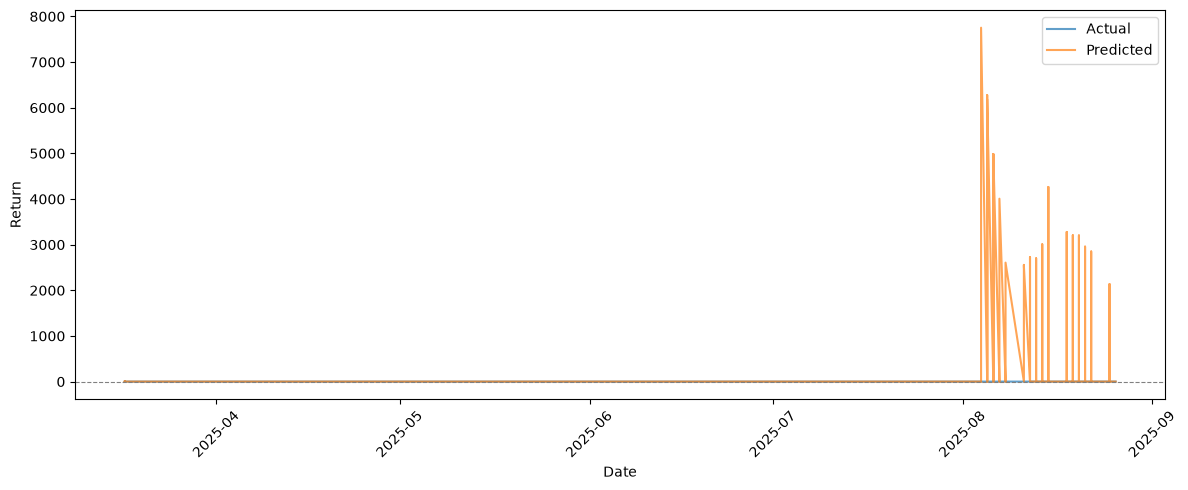

In [32]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index[:1000].get_level_values('datetime'), y_test[:1000].values, label="Actual", alpha=0.7)
plt.plot(y_test.index[:1000].get_level_values('datetime'), test_preds[:1000], label="Predicted", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# weird model behavior
let's take a closer look why

In [33]:
window_mask = (X_test.index.get_level_values("datetime") >= "2025-08-01") & \
              (X_test.index.get_level_values("datetime") <= "2025-10-31")

X_window = X_test[window_mask]

# Find the max absolute value per column within this window
extreme_features = X_window.abs().max().sort_values(ascending=False)
print(extreme_features.head(20))

VMA10     1.428469e+06
VMA20     1.306511e+06
VMA30     1.191711e+06
VMA5      1.163414e+06
VMA60     1.134807e+06
VSTD5     7.425222e+05
VSTD10    7.177325e+05
VSTD20    6.362311e+05
VSTD30    5.321856e+05
VSTD60    5.283010e+05
WVMA60    7.743047e+00
WVMA30    5.476000e+00
WVMA20    4.471536e+00
WVMA10    3.162123e+00
WVMA5     2.236063e+00
MAX20     1.084533e+00
MAX30     1.084533e+00
MAX60     1.084533e+00
MAX10     1.080804e+00
MAX5      1.065640e+00
dtype: float32


In [34]:
print(X_window.loc[X_window[extreme_features.index[0]].abs() > 10])

                           KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2025-08-04 000300.SH   0.008113  0.008113  1.000000  0.000000  0.000000   
           000985.CSI  0.011956  0.012273  0.974146  0.000000  0.000000   
           399303.SZ   0.018756  0.020416  0.918690  0.000000  0.000000   
           932000.CSI  0.021276  0.023648  0.899716  0.000000  0.000000   
2025-08-05 000300.SH   0.005651  0.007529  0.750668  0.000698  0.092762   
           000985.CSI  0.005546  0.006087  0.911088  0.000000  0.000000   
           399303.SZ   0.005012  0.006822  0.734707  0.000000  0.000000   
           932000.CSI  0.006997  0.007675  0.911673  0.000000  0.000000   
2025-08-06 000300.SH   0.003185  0.004478  0.711337  0.000785  0.175368   
           000985.CSI  0.006864  0.007379  0.930131  0.000038  0.005168   
           399303.SZ   0.011580  0.013081  0.885216  0.000057  0.004351   
           932000.CSI  0.

from the points we suspect the original volume data has extreme outliers

In [35]:
df_clean[df_clean['VOLUME'] < 100000]
######## compared to the summary of the VOLUME column below, we can tell the volumes these days
######## happen to be lower outliers, which indecates extreme values that are likely caused by
######## some special events

,date,OPEN,HIGH,LOW,CLOSE,PCT_CHG,VOLUME,AMT,code
33147,2025-08-04,4037.94,4070.70,4037.94,4070.70,0.39,16227.59,2959.77,000300.SH
33148,2025-08-05,4080.39,4106.30,4075.58,4103.45,0.80,17885.20,3069.34,000300.SH
33149,2025-08-06,4100.43,4116.71,4098.35,4113.49,0.24,17667.62,3076.75,000300.SH
33150,2025-08-07,4120.28,4129.74,4094.82,4114.67,0.03,19864.19,3581.08,000300.SH
33151,2025-08-08,4109.27,4122.21,4097.42,4104.97,-0.24,17317.12,3085.08,000300.SH
...,...,...,...,...,...,...,...,...,...
33158,2025-08-05,2891.05,2911.28,2889.09,2911.28,0.90,33913.92,4616.96,932000.CSI
33159,2025-08-06,2909.18,2946.02,2906.40,2946.02,1.19,36432.10,5129.89,932000.CSI
33160,2025-08-07,2947.04,2955.50,2930.82,2948.13,0.07,36405.34,5234.69,932000.CSI
33161,2025-08-08,2940.39,2949.08,2925.70,2941.47,-0.22,36524.41,5115.91,932000.CSI


In [36]:
df_clean.describe()

,date,OPEN,HIGH,LOW,CLOSE,PCT_CHG,VOLUME,AMT
count,18378,18378.000000,18378.000000,18378.000000,18378.000000,18378.000000,1.837800e+04,1.837800e+04
mean,2022-03-18 05:03:56.238981376,27338.070141,27603.334880,27037.386902,27361.214834,0.035225,2.250356e+10,2.756215e+11
min,2018-01-02 00:00:00,1373.960900,1424.547200,1373.960900,1395.925700,-13.700842,1.622759e+04,2.959770e+03
25%,2020-02-12 00:00:00,3015.672400,3040.408700,2995.985725,3017.881100,-0.684799,6.148477e+09,7.981200e+10
50%,2022-03-17 12:00:00,4873.175900,4908.080400,4838.159500,4876.122900,0.078148,1.518502e+10,1.806578e+11
75%,2024-04-25 00:00:00,6664.765600,6717.251400,6611.958775,6669.111000,0.844302,2.889506e+10,3.258425e+11
max,2026-06-05 00:00:00,644904.865100,646033.852600,638503.456700,645222.301600,11.755436,2.790992e+11,3.920455e+12
std,NaN,80351.127822,81126.692143,79441.516435,80397.990440,1.496859,2.511445e+10,3.474297e+11


we plot the graph to get a better sense of what is happening

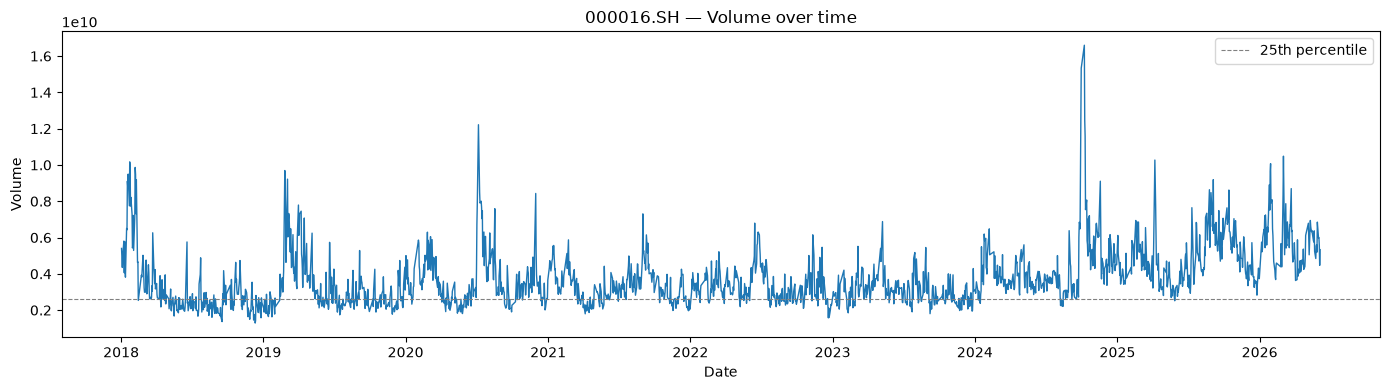

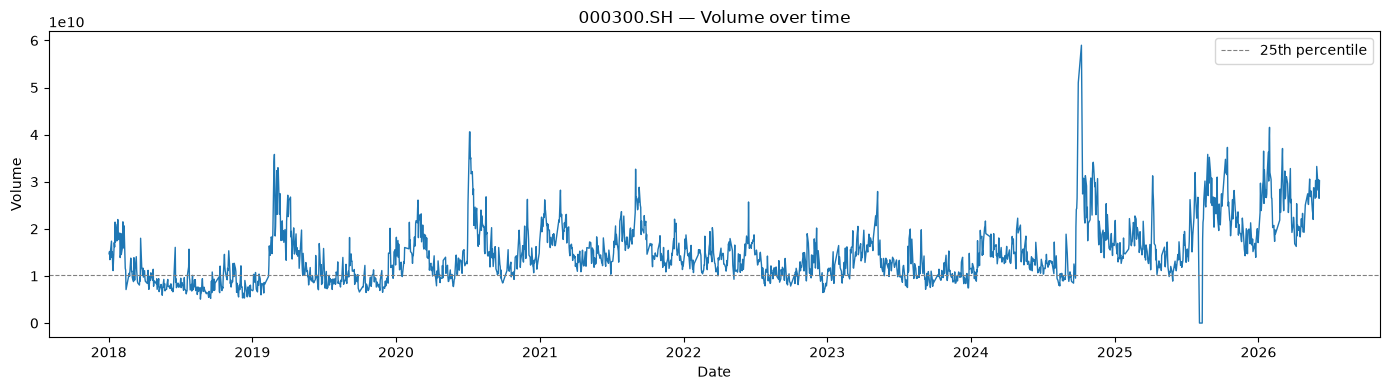

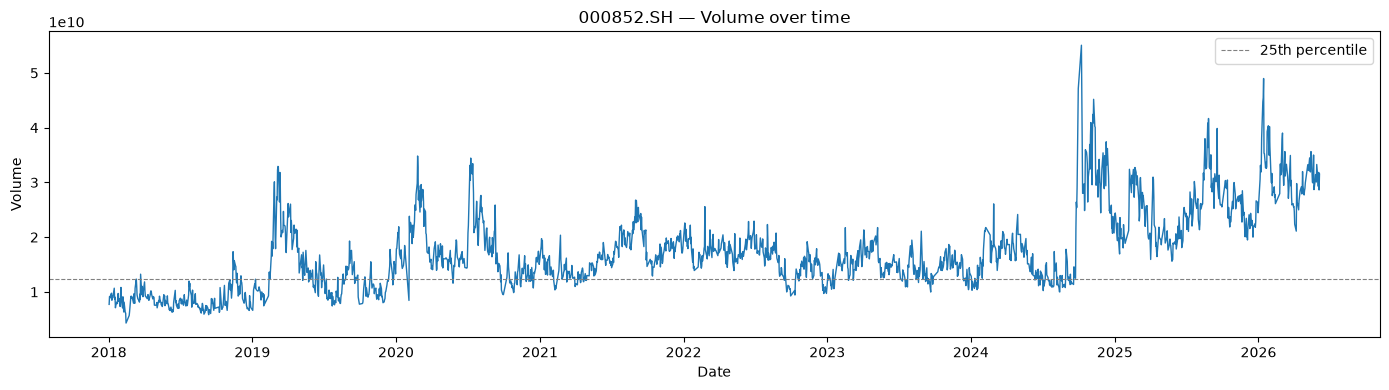

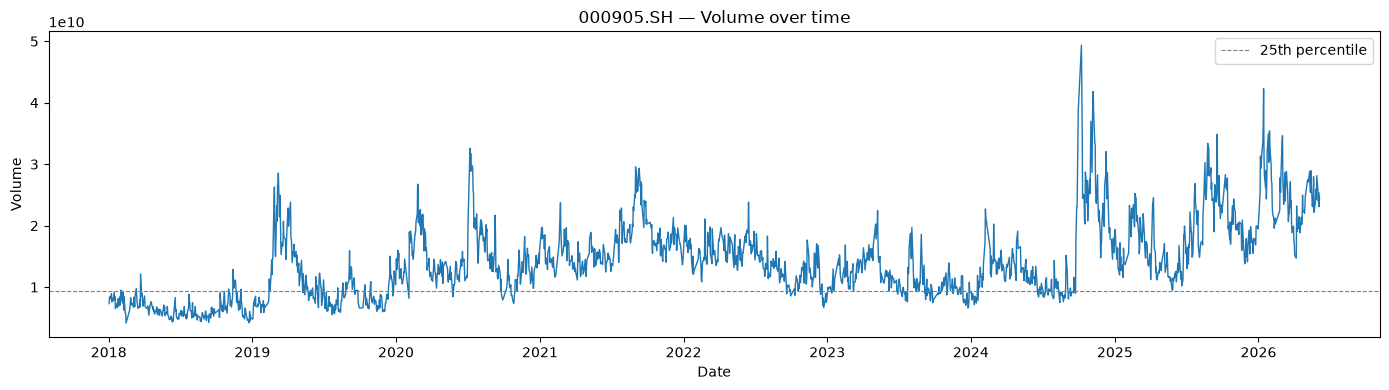

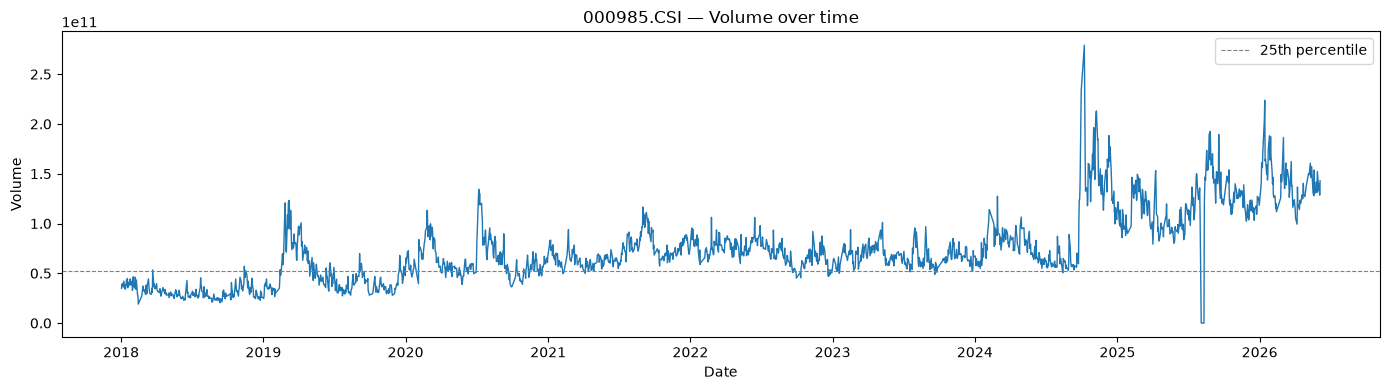

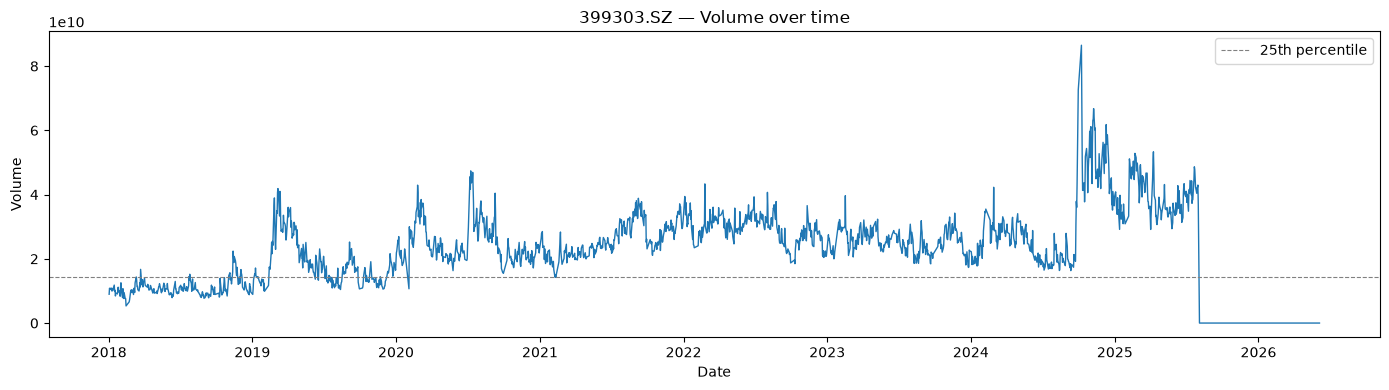

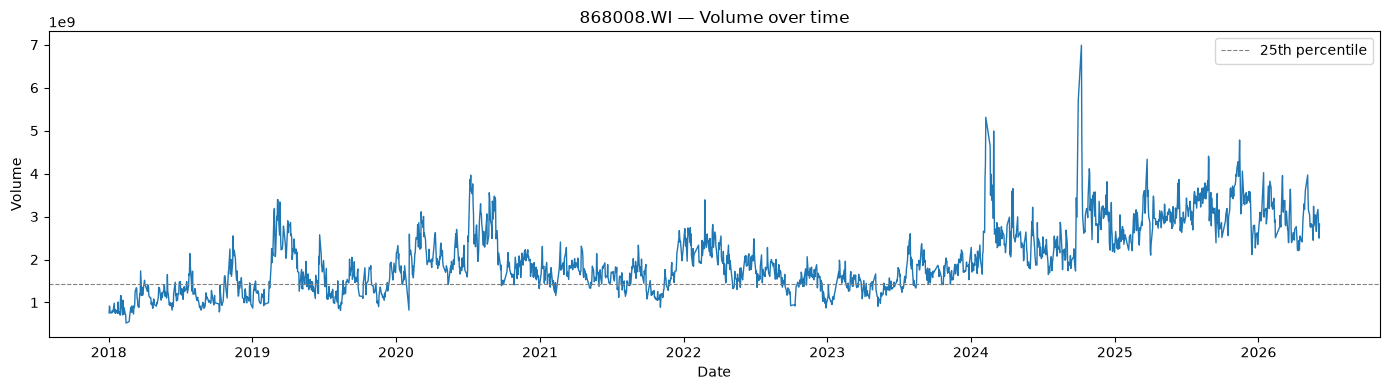

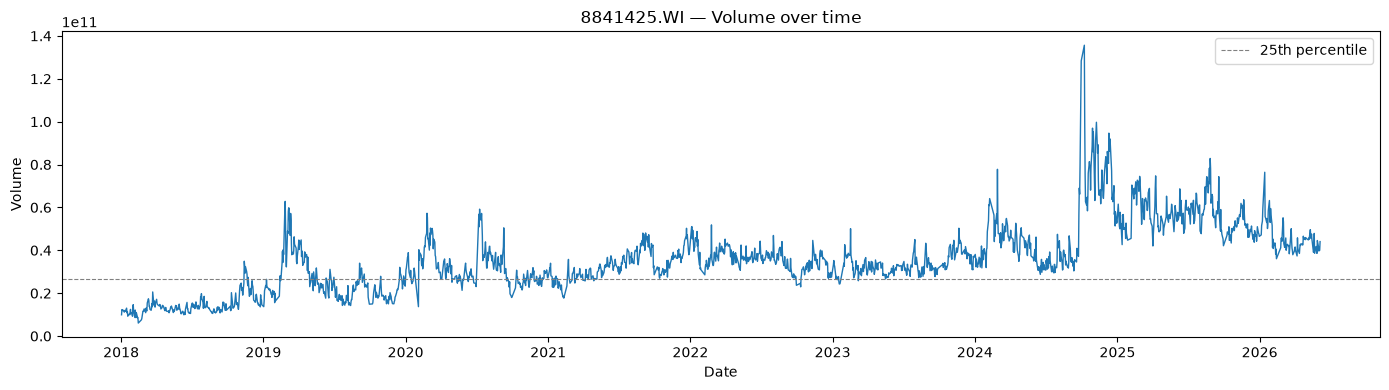

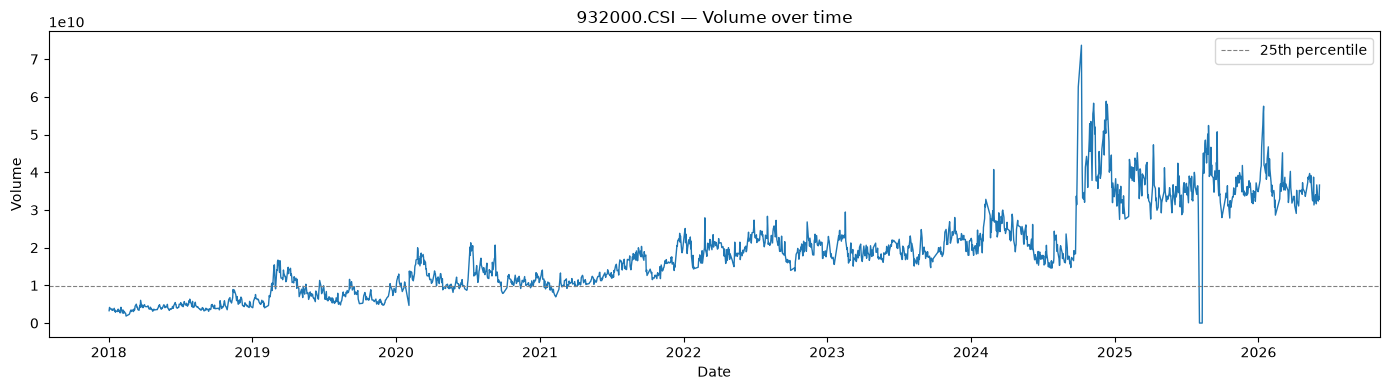

In [37]:
for code in df_clean['code'].unique():
    sub = df_clean[df_clean['code'] == code].sort_values('date')
    
    plt.figure(figsize=(14, 4))
    plt.plot(sub['date'], sub['VOLUME'], linewidth=1)
    plt.axhline(sub['VOLUME'].quantile(0.25), color='gray', linestyle='--', linewidth=0.8, label='25th percentile')
    plt.title(f"{code} — Volume over time")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.legend()
    plt.tight_layout()
    plt.show()

from other data and events around the date, we assume that this is a data cleaning issue, probably unit change

In [48]:
'''
932000.CSI
399303.SZ # changed ever since
000985.CSI
000300.SH
'''

for code in ['932000.CSI', '399303.SZ', '000985.CSI', '000300.SH']:
    sub = df_clean[df_clean['code'] == code].sort_values('date')

    print(sub[sub['VOLUME'] == min(sub['VOLUME'])])

            date    OPEN     HIGH     LOW    CLOSE  PCT_CHG    VOLUME  \
33157 2025-08-04  2825.2  2885.31  2818.5  2885.31     1.56  30162.02   

           AMT        code  
33157  4138.26  932000.CSI  
            date       OPEN       HIGH       LOW      CLOSE  PCT_CHG  \
34767 2025-12-18  9481.0264  9617.0037  9476.703  9524.4794    -0.18   

         VOLUME      AMT       code  
34767  33854.58  5405.21  399303.SZ  
            date     OPEN     HIGH      LOW    CLOSE  PCT_CHG     VOLUME  \
33152 2025-08-04  5138.14  5199.57  5136.51  5199.57     0.75  101457.82   

            AMT        code  
33152  14813.17  000985.CSI  
            date     OPEN    HIGH      LOW   CLOSE  PCT_CHG    VOLUME  \
33147 2025-08-04  4037.94  4070.7  4037.94  4070.7     0.39  16227.59   

           AMT       code  
33147  2959.77  000300.SH  


/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/1487961545.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


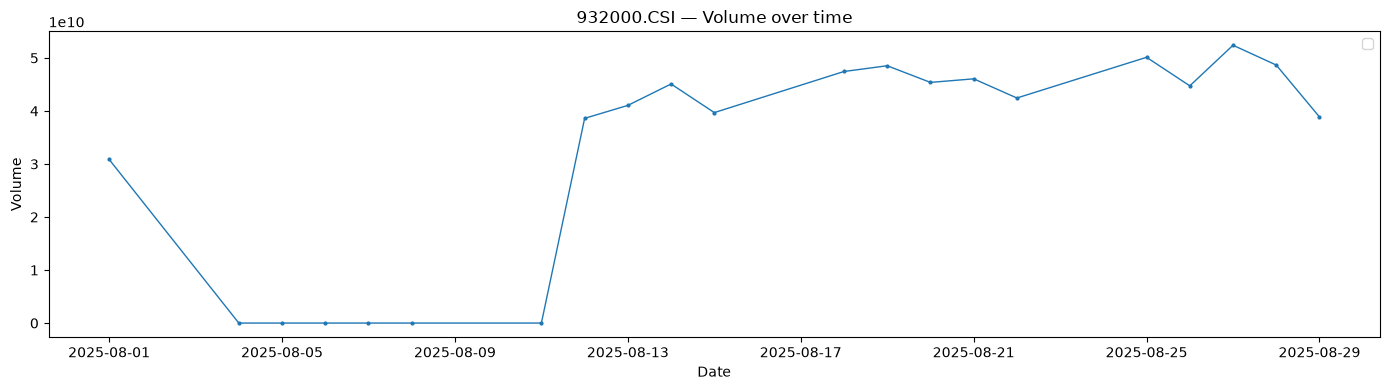

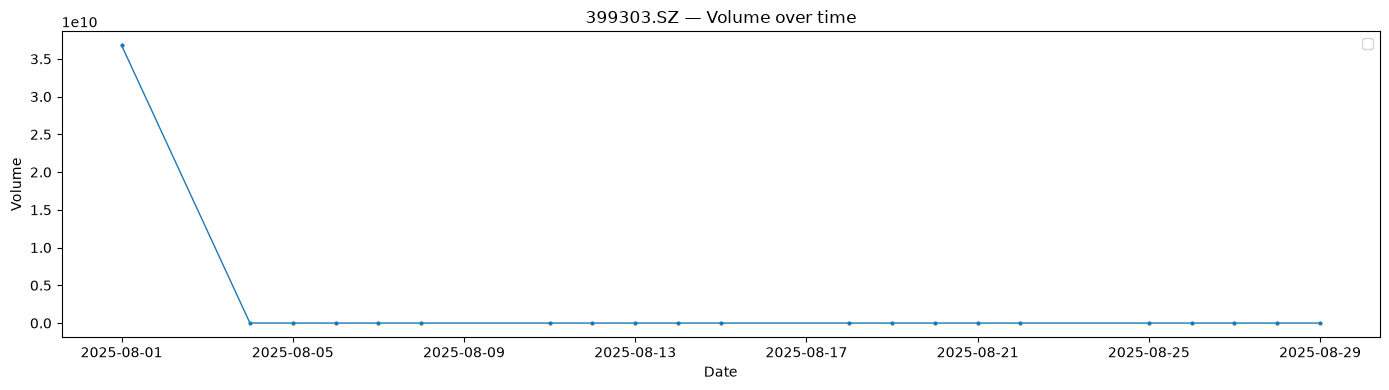

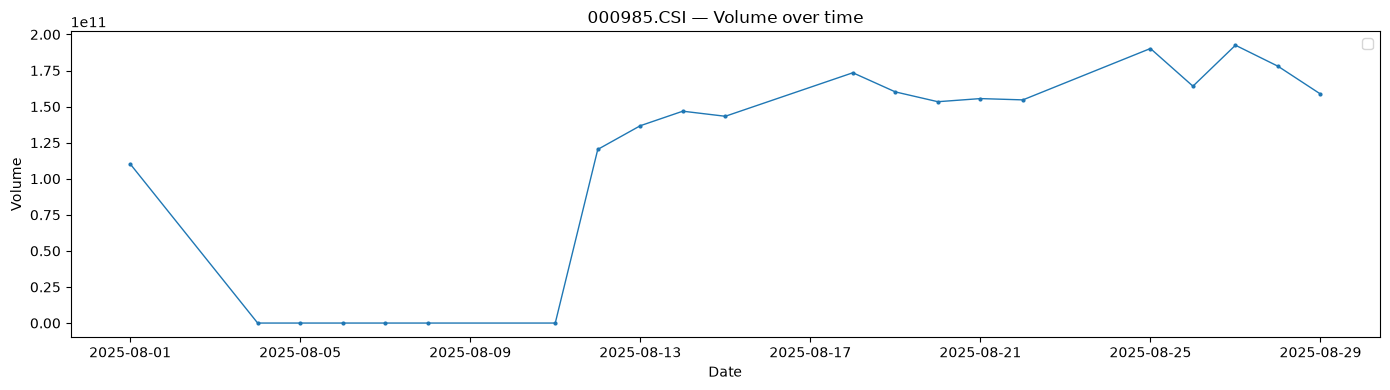

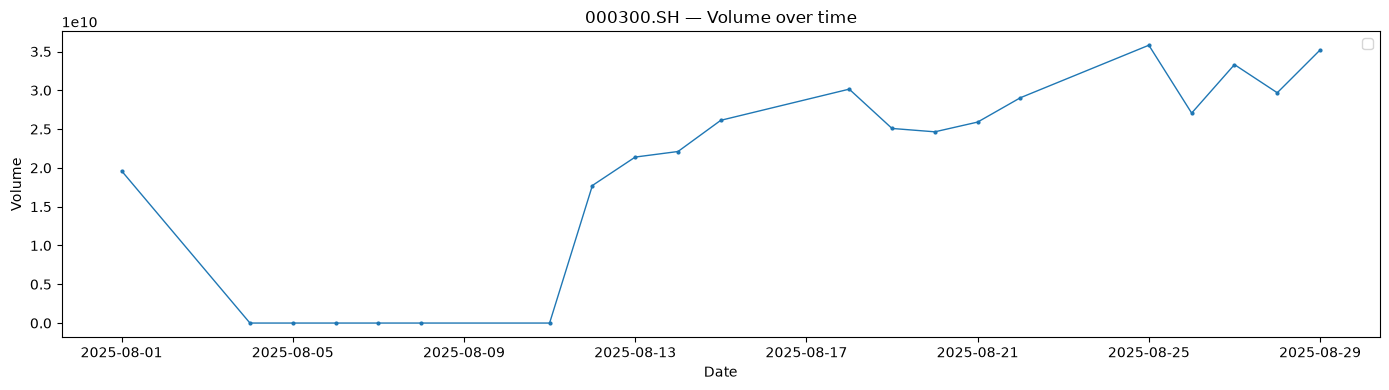

In [51]:
for code in ['932000.CSI', '399303.SZ', '000985.CSI', '000300.SH']:
    sub = df_clean[df_clean['code'] == code].sort_values('date')
    sub = sub[('2025-08-01' <= sub['date']) & (sub['date'] <= '2025-08-31')]
    
    plt.figure(figsize=(14, 4))
    plt.plot(sub['date'], sub['VOLUME'], marker='.', markersize=4, linewidth=1)
    plt.title(f"{code} — Volume over time")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.legend()
    plt.tight_layout()
    plt.show()

see the magnitue

In [53]:
for code in ['932000.CSI', '399303.SZ', '000985.CSI', '000300.SH']:
    sub = df_clean[df_clean['code'] == code].sort_values('date')

    vol_aug01 = sub[sub['date'] == '2025-08-01']['VOLUME'].values[0]
    vol_aug04 = sub[sub['date'] == '2025-08-04']['VOLUME'].values[0]

    print(vol_aug01 / vol_aug04)
######## all around 1000000
######## now lets time it back

1023203.6017481588
1057960.4244255337
1087451.1940035769
1209186.4904153976


see if by multiplying 1_000_000 can do

/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000
/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


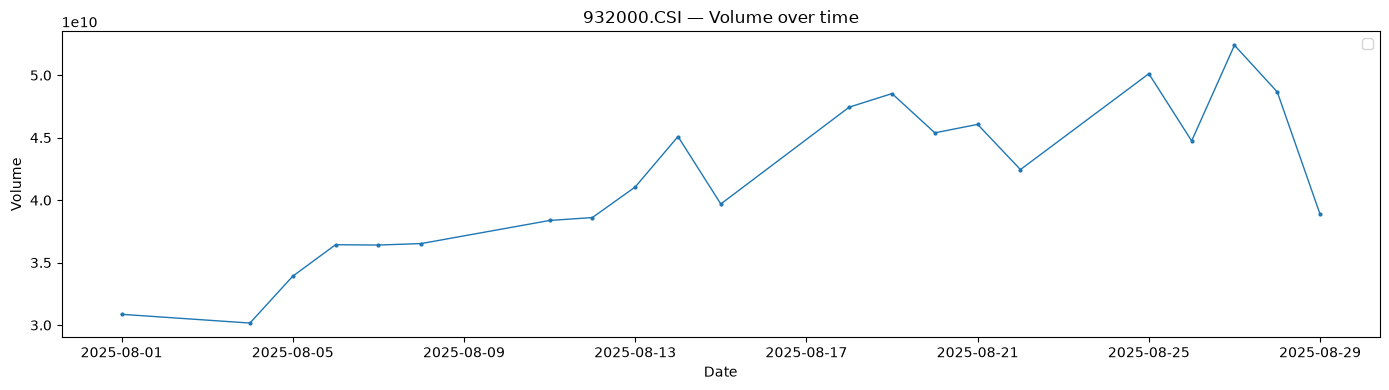

/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000
/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


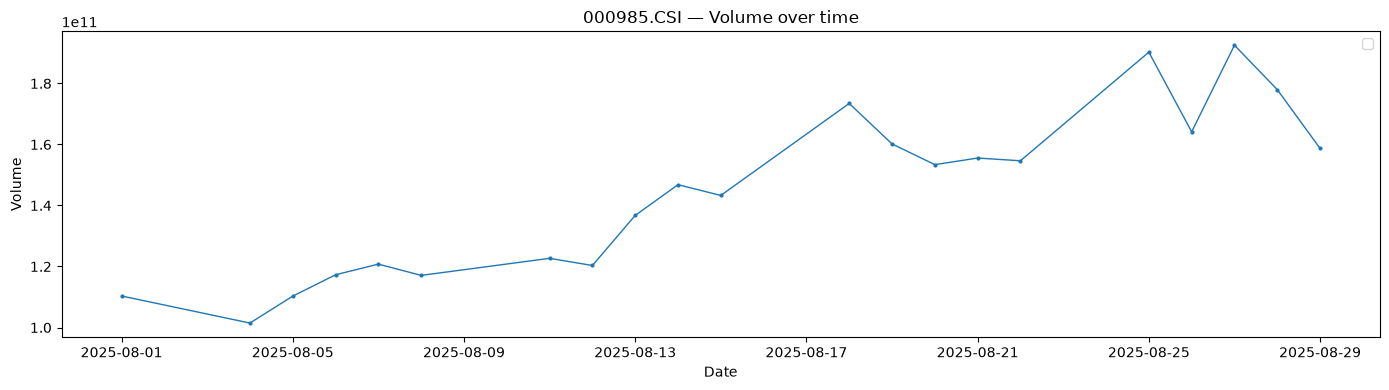

/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000
/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


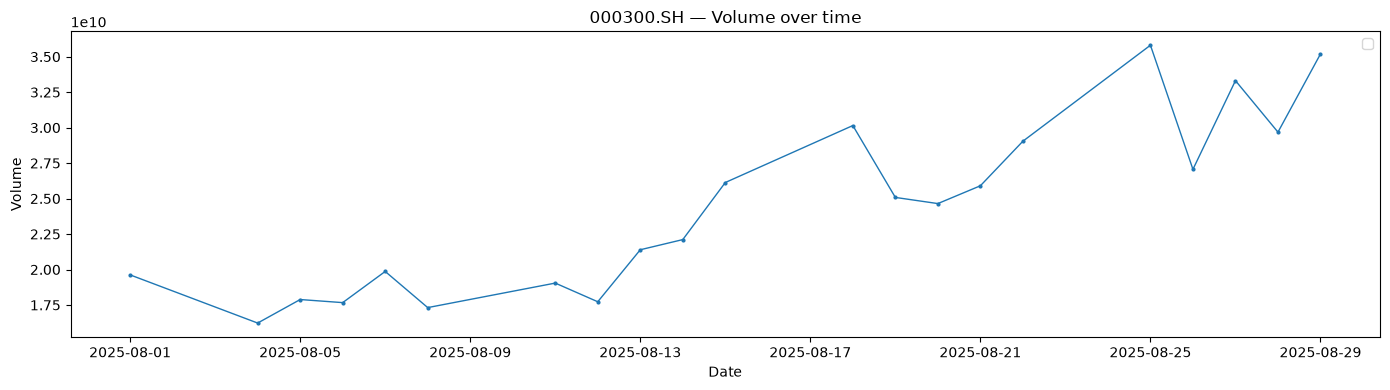

/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_1471/903481031.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


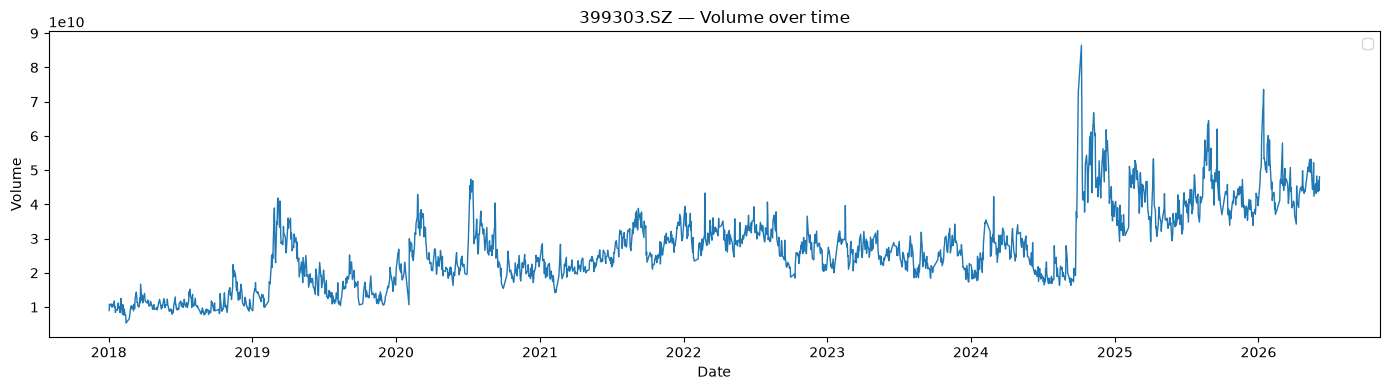

In [65]:
for code in ['932000.CSI', '000985.CSI', '000300.SH']:
    sub = df_clean[df_clean['code'] == code].sort_values('date')
    sub = sub[('2025-08-01' <= sub['date']) & (sub['date'] <= '2025-08-31')]

    fix_dates = ['2025-08-04', '2025-08-05', '2025-08-06','2025-08-07','2025-08-08','2025-08-11']
    sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000

    plt.figure(figsize=(14, 4))
    plt.plot(sub['date'], sub['VOLUME'], marker='.', markersize=4, linewidth=1)
    plt.title(f"{code} — Volume over time")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.legend()
    plt.tight_layout()
    plt.show()
###### yep now we know how to fix these data points

# 399303.SZ
sub = df_clean[df_clean['code'] == '399303.SZ'].sort_values('date')
sub.loc[sub['date'] >= '2025-08-04', 'VOLUME'] *= 1000000

plt.figure(figsize=(14, 4))
plt.plot(sub['date'], sub['VOLUME'], linewidth=1)
plt.title("399303.SZ — Volume over time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.tight_layout()
plt.show()

####### then i double checked, it is the UNIT problem
    

now we've made sure this will work (also comparing to other data sources)
we change the original data

In [21]:
######## data cleaning
for code in ['932000.CSI', '000985.CSI', '000300.SH']:
    sub = df_clean[df_clean['code'] == code].sort_values('date')

    fix_dates = ['2025-08-04', '2025-08-05', '2025-08-06','2025-08-07','2025-08-08','2025-08-11']
    sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000

    df_clean[df_clean['code'] == code] = sub

# 399303.SZ
sub = df_clean[df_clean['code'] == '399303.SZ'].sort_values('date')
sub.loc[sub['date'] >= '2025-08-04', 'VOLUME'] *= 1000000
df_clean[df_clean['code'] == '399303.SZ'] = sub


/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_15820/3956599969.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000
/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_15820/3956599969.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sub.loc[sub['date'].isin(fix_dates), 'VOLUME'] *= 1000000
/var/folders/6c/t8w6501913q66v3rtpr_7gfc0000gn/T/ipykernel_15820/3956599969.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future vers

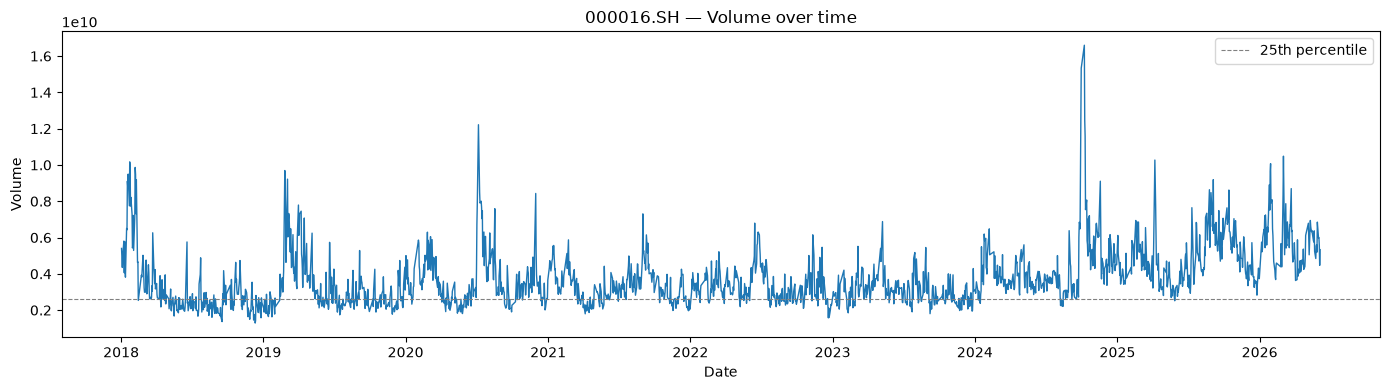

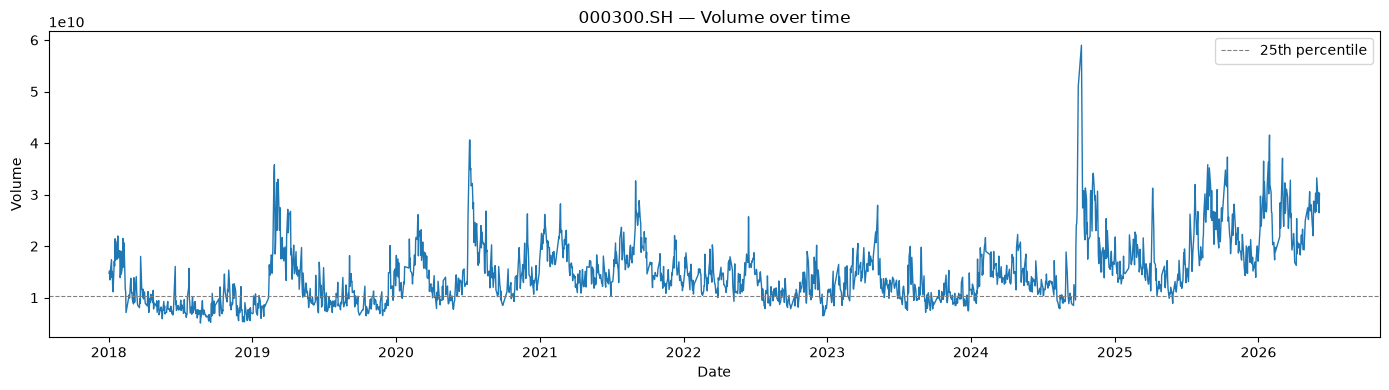

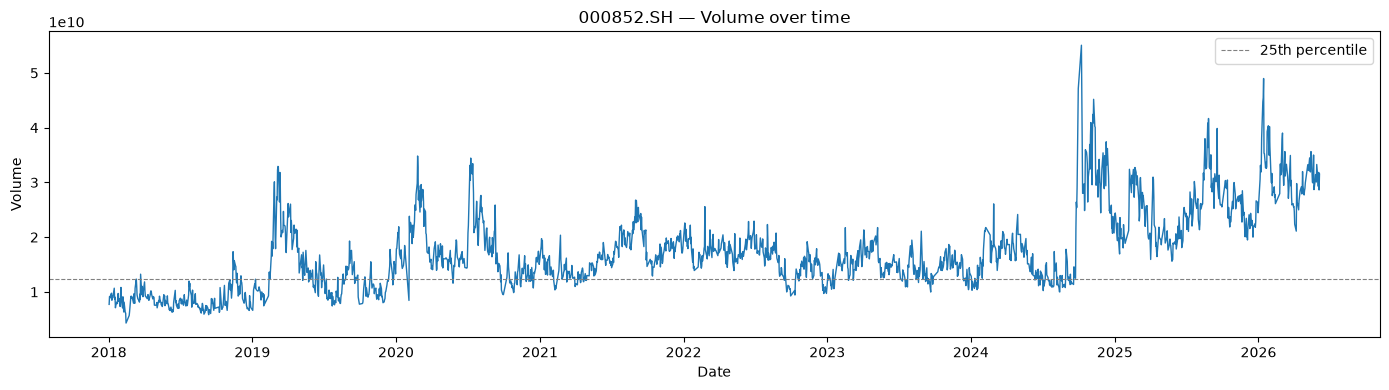

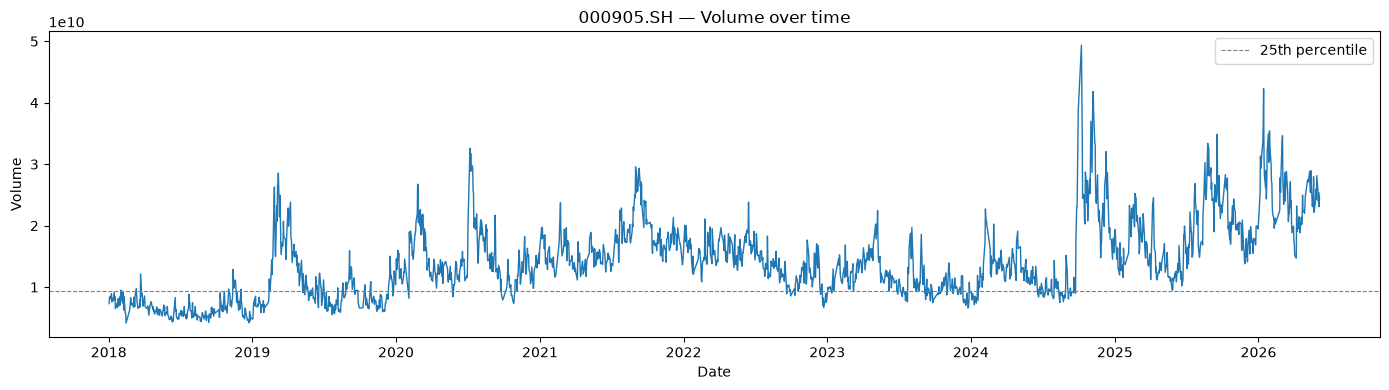

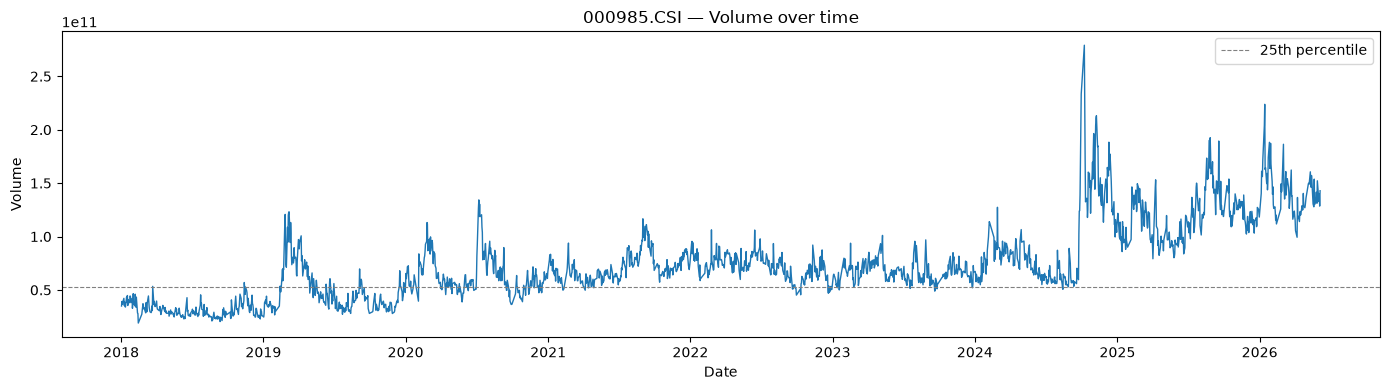

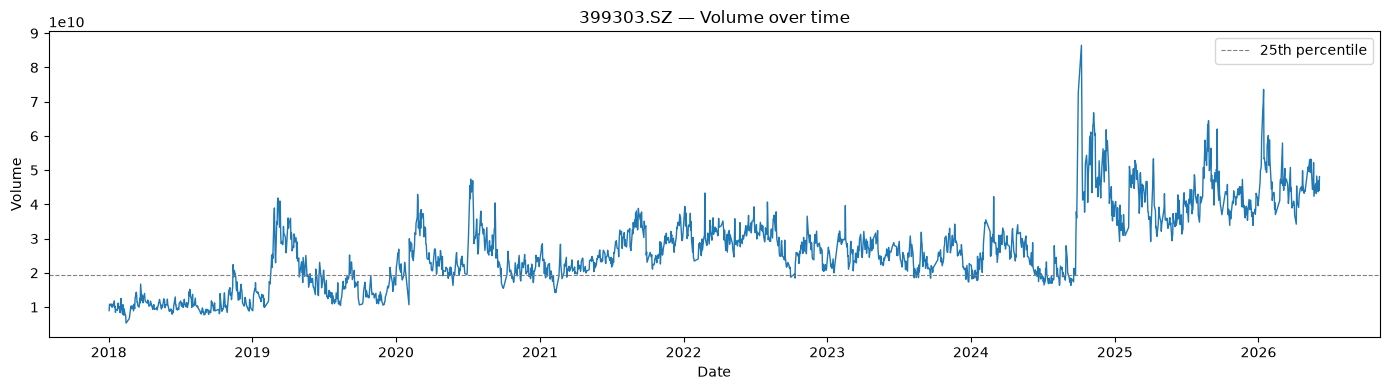

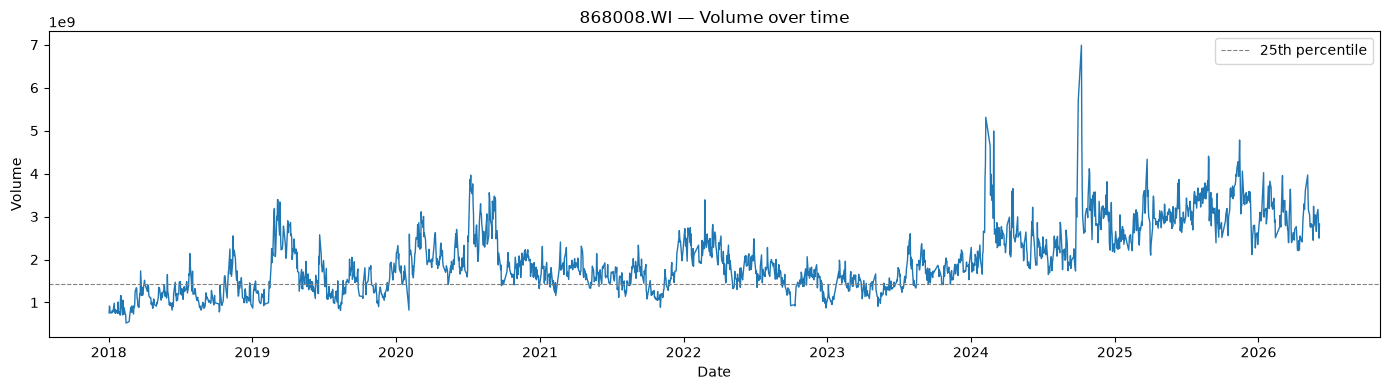

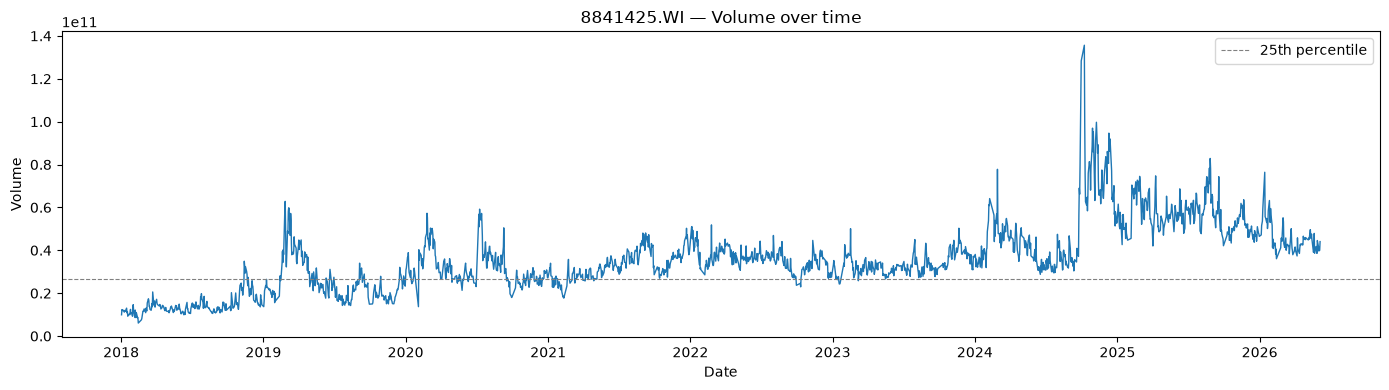

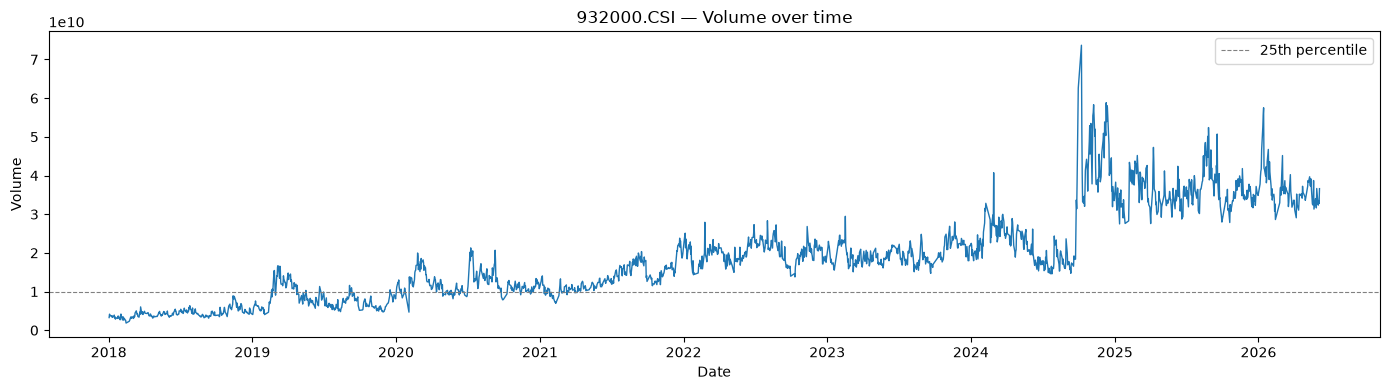

In [22]:
# check
for code in df_clean['code'].unique():
    sub = df_clean[df_clean['code'] == code].sort_values('date')
    
    plt.figure(figsize=(14, 4))
    plt.plot(sub['date'], sub['VOLUME'], linewidth=1)
    plt.axhline(sub['VOLUME'].quantile(0.25), color='gray', linestyle='--', linewidth=0.8, label='25th percentile')
    plt.title(f"{code} — Volume over time")
    plt.xlabel("Date")
    plt.ylabel("Volume")
    plt.legend()
    plt.tight_layout()
    plt.show()

take a look at the peaks to see if its also a data flaw

In [ ]:
for code in df_clean['code'].unique():
    sub = df_clean[df_clean['code'] == code].sort_values('date')

    print(sub[sub['VOLUME'] == max(sub['VOLUME'])])

####### okay this will show when they all reached the highest volume
####### just to see if the peak is a unit problem too
####### 24/10/08 is a special day for the cn stock market

           date       OPEN       HIGH        LOW      CLOSE   PCT_CHG  \
1638 2024-10-08  3016.8743  3016.8743  2780.0303  2853.1376  3.546964   

            VOLUME           AMT       code  
1638  1.659732e+10  3.322534e+11  000016.SH  
           date       OPEN       HIGH        LOW      CLOSE   PCT_CHG  \
3473 2024-10-08  4450.3675  4450.3675  4094.3519  4256.0962  5.929575   

            VOLUME           AMT       code  
3473  5.898679e+10  1.130387e+12  000300.SH  
           date      OPEN      HIGH        LOW      CLOSE   PCT_CHG  \
5308 2024-10-08  6437.113  6437.113  5861.3216  6201.9854  8.638547   

            VOLUME           AMT       code  
5308  5.505908e+10  6.375206e+11  000852.SH  
           date       OPEN       HIGH        LOW      CLOSE  PCT_CHG  \
7143 2024-10-08  6417.8142  6417.8142  5868.8525  6155.5817  7.18003   

            VOLUME           AMT       code  
7143  4.935464e+10  5.792633e+11  000905.SH  
           date       OPEN       HIGH        LOW  

# y = 0 model

In [ ]:
####### this is to check if the model is better than predicting everything as 0
test_preds_mlp = zeros = np.zeros(len(X_test))
pred_series_mlp = pd.Series(test_preds_mlp, index=X_test.index)

# MSE
mse_0 = np.mean((pred_series_mlp - y_test) ** 2)
# MAE
mae_0 = np.mean(np.abs(pred_series_mlp - y_test))

print('mse:', mse_0, 'mae:', mae_0)

# alpha158 and ridge AGAIN

In [68]:
# do the alpha and input ALL OVER AGAIN :((((
output_dir = os.path.expanduser("/Users/hanxi/Desktop/work_space/intern_1_py/raw_data/muti_stock_cleaned")
os.makedirs(output_dir, exist_ok=True)

for code, group in df_clean.groupby('code'):
    out = group[['date', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME']].copy()
    out.columns = ['date', 'open', 'high', 'low', 'close', 'volume']
    out['factor'] = 1.0   # if you don't have a real adjustment factor field
    out['vwap'] = group['AMT'] / group['VOLUME']

    out = out.sort_values('date')
    out_path = os.path.join(output_dir, f"{code}.csv")
    out.to_csv(out_path, index=False)
    print(f"Saved {code}: {len(out)} rows")

Saved 000016.SH: 2042 rows
Saved 000300.SH: 2042 rows
Saved 000852.SH: 2042 rows
Saved 000905.SH: 2042 rows
Saved 000985.CSI: 2042 rows
Saved 399303.SZ: 2042 rows
Saved 868008.WI: 2042 rows
Saved 8841425.WI: 2042 rows
Saved 932000.CSI: 2042 rows


In [23]:
qlib.init(provider_uri="~/.qlib/qlib_data/my_custom_data", region=REG_CN)

handler = Alpha158(
    start_time="2018-01-02",
    end_time="2026-06-05",
    fit_start_time="2018-01-02",
    fit_end_time="2023-12-29",
    instruments=['000016.SH', '000300.SH', '000852.SH', '000905.SH', '000985.CSI',
       '399303.SZ', '868008.WI', '8841425.WI', '932000.CSI'],
)

data = handler.fetch()
print(data.shape)
print(data.head())

[15820:MainThread](2026-07-10 15:03:12,397) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[15820:MainThread](2026-07-10 15:03:13,103) INFO - qlib.Initialization - [__init__.py:75] - qlib successfully initialized based on client settings.
[15820:MainThread](2026-07-10 15:03:13,103) INFO - qlib.Initialization - [__init__.py:77] - data_path={'__DEFAULT_FREQ': PosixPath('/Users/hanxi/.qlib/qlib_data/my_custom_data')}
[15820:MainThread](2026-07-10 15:03:36,288) INFO - qlib.timer - [log.py:127] - Time cost: 23.183s | Loading data Done
[15820:MainThread](2026-07-10 15:03:36,303) INFO - qlib.timer - [log.py:127] - Time cost: 0.007s | DropnaLabel Done
[15820:MainThread](2026-07-10 15:03:37,038) INFO - qlib.timer - [log.py:127] - Time cost: 0.734s | CSZScoreNorm Done
[15820:MainThread](2026-07-10 15:03:37,039) INFO - qlib.timer - [log.py:127] - Time cost: 0.750s | fit & process data Done
[15820:MainThread](2026-07-10 15:03:37,039) INFO - qlib.timer - [log.py:127] - Time co

(18378, 159)
                           KMID      KLEN     KMID2       KUP      KUP2  \
datetime   instrument                                                     
2018-01-02 000016.SH   0.014369  0.015603  0.920932  0.001234  0.079068   
           000300.SH   0.010430  0.010524  0.991128  0.000093  0.008872   
           000852.SH   0.009172  0.009959  0.920998  0.000018  0.001800   
           000905.SH   0.011029  0.011887  0.927793  0.000061  0.005129   
           000985.CSI  0.009782  0.009847  0.993427  0.000065  0.006573   

                           KLOW     KLOW2      KSFT     KSFT2     OPEN0  ...  \
datetime   instrument                                                    ...   
2018-01-02 000016.SH   0.000000  0.000000  0.013135  0.841863  0.985835  ...   
           000300.SH   0.000000  0.000000  0.010337  0.982256  0.989677  ...   
           000852.SH   0.000769  0.077202  0.009923  0.996400  0.990911  ...   
           000905.SH   0.000797  0.067078  0.011765  0.989743

In [24]:
# data splitting
X =  data.iloc[:, 0:158]
y = data.iloc[:, 158]

keep = X.notna().all(axis=1) & y.notna()
X, y = X[keep], y[keep]

train_dates = slice("2018-01-02", "2023-12-29")
valid_dates = slice("2024-01-02", "2025-03-14")
test_dates  = slice("2025-03-17", "2026-06-05")

X_train, y_train = X.loc[train_dates], y.loc[train_dates]
X_valid, y_valid = X.loc[valid_dates], y.loc[valid_dates]
X_test,  y_test  = X.loc[test_dates],  y.loc[test_dates]

# Rige
best_alpha, best_score = None, np.inf
for alpha in np.logspace(-3, 3, 20):
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train.values.ravel())
    preds = model.predict(X_valid)
    score = mean_squared_error(y_valid, preds)
    if score < best_score:
        best_alpha, best_score = alpha, score

final_model = Ridge(alpha=best_alpha)
final_model.fit(X_train, y_train.values.ravel())

# evaluate
test_preds = final_model.predict(X_test)

results = pd.DataFrame({"pred": test_preds, "actual": y_test.values}, index=y_test.index)

mse = mean_squared_error(results["actual"], results["pred"])
mae = (results["actual"] - results["pred"]).abs().mean()
pearson = results["pred"].corr(results["actual"])

daily_ic = results.groupby(level="datetime").apply(
    lambda g: g["pred"].corr(g["actual"], method="spearman")
)
rank_ic = daily_ic.mean()

print('MSE:', mse, 'MAE:', mae, 'corr:', pearson, 'rank_ic:', rank_ic)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.7750892068497706e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


MSE: 0.00018983546760864556 MAE: 0.009768844 corr: 0.06227176655449924 rank_ic: 0.016271186440677963


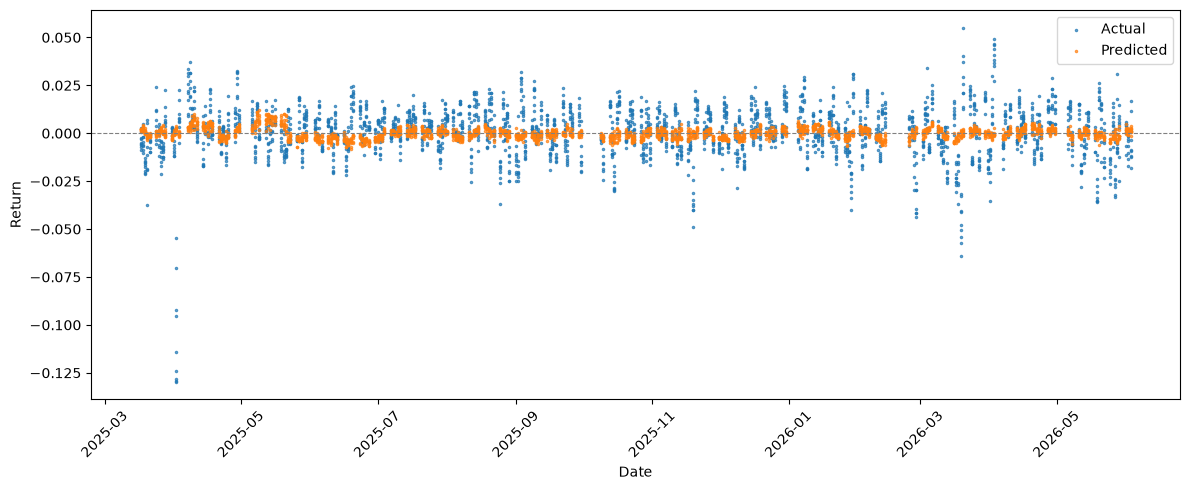

"\nit might be getting the general up/down direction of returns right in raw-value terms slightly better than \nit's getting the relative ranking across stocks right on any given day\n"

In [97]:
plt.figure(figsize=(12, 5))
plt.scatter(y_test.index.get_level_values('datetime'), y_test.values, s = 3, label="Actual", alpha=0.7, linewidth=0.8)
plt.scatter(y_test.index.get_level_values('datetime'), test_preds, s = 3, label="Predicted", alpha=0.7, linewidth=0.8)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

'''
it might be getting the general up/down direction of returns right in raw-value terms slightly better than 
it's getting the relative ranking across stocks right on any given day
'''

# LightGBM

In [25]:
# LightGBM
train_set = lgb.Dataset(X_train, label=y_train)
valid_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set)

params = {
    "objective": "regression",
    "metric": "mse",
    "learning_rate": 0.01,
    "num_leaves": 31,
    "max_depth": -1,
    "verbose": -1,
}

lgb_model = lgb.train(
    params,
    train_set,
    num_boost_round=500,
    valid_sets=[valid_set],
    callbacks=[lgb.early_stopping(stopping_rounds=20)] # watches validation loss
)

# get the important parameters 
importances = pd.Series(lgb_model.feature_importance(importance_type="gain"),
                         index=X_train.columns)
print(importances.sort_values(ascending=False).head(10))

test_preds_lgb = lgb_model.predict(X_test, num_iteration = lgb_model.best_iteration)
pred_series_lgb = pd.Series(test_preds_lgb, index=X_test.index)

results_lgb = pd.DataFrame({"pred": test_preds_lgb, "actual": y_test.values}, index=y_test.index)

# MSE
mse_lgb = np.mean((pred_series_lgb - y_test) ** 2)
# MAE
mae_lgb = np.mean(np.abs(pred_series_lgb - y_test))
# pearson corr
p_corr_lgb = pred_series_lgb.corr(y_test)
# rank ic
daily_ic = results_lgb.groupby(level="datetime").apply(
    lambda g: g["pred"].corr(g["actual"], method="spearman")
)
rank_ic = daily_ic.mean()

print('MSE:', mse_lgb, 'MAE:', mae_lgb, 'corr:', p_corr_lgb, 'rank_ic:', rank_ic)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[27]	valid_0's l2: 0.000409778
VMA30     0.649197
STD20     0.357634
OPEN0     0.319709
KMID      0.267567
VSTD5     0.234563
KLOW      0.222786
RSQR10    0.204987
RESI30    0.190657
MAX5      0.185217
CORD5     0.177477
dtype: float64
MSE: 0.00018698142311200706 MAE: 0.0096016180204029 corr: 0.008931415230085752 rank_ic: 0.0003920664536337951


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


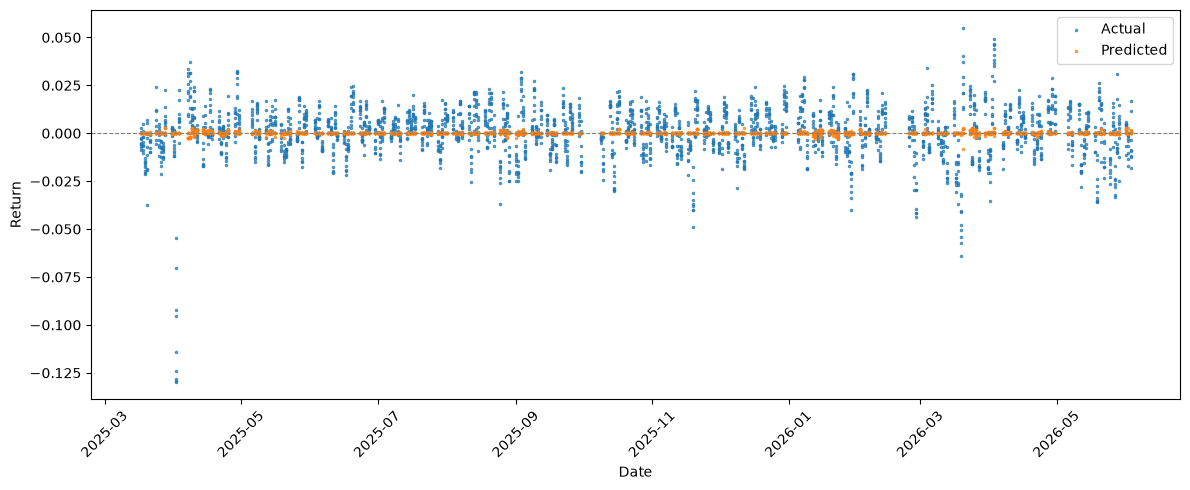

In [96]:
plt.figure(figsize=(12, 5))
plt.scatter(y_test.index.get_level_values('datetime'), y_test.values, s = 3, label="Actual", alpha=0.7, linewidth=0.8)
plt.scatter(y_test.index.get_level_values('datetime'), test_preds_lgb, s = 3, label="Predicted", alpha=0.7, linewidth=0.8)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# MLP
- grid and optimizer for tuning

In [48]:
# MLP
param_grid = [
    {"hidden_layer_sizes": (64, 32, 16), "alpha": 0.01},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.01},
    {"hidden_layer_sizes": (128, 64), "alpha": 0.001},
    {"hidden_layer_sizes": (128, 64, 32), "alpha": 0.001},
]

for para in param_grid:
    mlp_model = MLPRegressor(
        hidden_layer_sizes= para["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha= para['alpha'],                    
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=False,           
        random_state=42,  
    )

    mlp_model.fit(X_train, y_train)

    test_preds_mlp = mlp_model.predict(X_test)
    pred_series_mlp = pd.Series(test_preds_mlp, index=X_test.index)

    results_mlp = pd.DataFrame({"pred": test_preds_mlp, "actual": y_test.values}, index=y_test.index)

    # MSE
    mse_mlp = np.mean((pred_series_mlp - y_test) ** 2)
    # MAE
    mae_mlp = np.mean(np.abs(pred_series_mlp - y_test))
    # pearson corr
    p_corr_mlp = pred_series_mlp.corr(y_test)
    # rank ic
    daily_ic_mlp = results_mlp.groupby(level="datetime").apply(
        lambda g: g["pred"].corr(g["actual"], method="spearman")
    )
    rank_ic_mlp = daily_ic_mlp.mean()

    print('MSE:', mse_mlp, 'MAE:', mae_mlp, 'corr:', p_corr_mlp, 'rank_ic:', rank_ic_mlp)
# {"hidden_layer_sizes": (128, 64), "alpha": 0.01} produced the best result

MSE: 0.0002041795 MAE: 0.0100682145 corr: 0.010817957345108396 rank_ic: 0.029661016949152543
MSE: 0.0002339742 MAE: 0.011262827 corr: 0.019878557630595938 rank_ic: 0.006497175141242934
MSE: 0.0002482175 MAE: 0.011701869 corr: 0.013522073821662673 rank_ic: 0.01926553672316384
MSE: 0.00023942573 MAE: 0.01125049 corr: -0.014242458680271864 rank_ic: -0.007175141242937858


stability check: set seed to different numbers then check if the model still performs well

In [52]:
ic = []
for seed in [42, 5, 47, 467, 76, 15]:
    mlp_model = MLPRegressor(
        hidden_layer_sizes= (64, 32, 16),
        activation="relu",
        solver="adam",
        alpha= 0.01,
        random_state=seed,                    
        max_iter=1000,
        early_stopping=False,        
    )
    mlp_model.fit(X_train, y_train)

    test_preds_mlp = mlp_model.predict(X_test)                     ###### used valid to check, test set actually performs even worse
    pred_series_mlp = pd.Series(test_preds_mlp, index=X_test.index)

    results_mlp = pd.DataFrame({"pred": test_preds_mlp, "actual": y_test.values}, index=y_test.index)

    # MSE
    mse_mlp = np.mean((pred_series_mlp - y_test) ** 2)
    # MAE
    mae_mlp = np.mean(np.abs(pred_series_mlp - y_test))
    # pearson corr
    p_corr_mlp = pred_series_mlp.corr(y_test)
    # rank ic
    daily_ic_mlp = results_mlp.groupby(level="datetime").apply(
        lambda g: g["pred"].corr(g["actual"], method="spearman")
    )
    rank_ic_mlp = daily_ic_mlp.mean()
    ic.append(rank_ic_mlp)

    print(seed, ':', 'MSE:', mse_mlp, 'MAE:', mae_mlp, 'corr:', p_corr_mlp, 'rank_ic:', rank_ic_mlp)

print('mean:', np.mean(ic), 'std:', np.std(ic))

42 : MSE: 0.0002041795 MAE: 0.0100682145 corr: 0.010817957345108396 rank_ic: 0.029661016949152543
5 : MSE: 0.00019126877 MAE: 0.009814686 corr: 0.03139419654051915 rank_ic: 0.0024293785310734364
47 : MSE: 0.00021939327 MAE: 0.010710093 corr: -0.0482762234573616 rank_ic: -0.014576271186440674
467 : MSE: 0.00022184828 MAE: 0.010836663 corr: 0.021566216766886324 rank_ic: 0.006158192090395481
76 : MSE: 0.0002168153 MAE: 0.010844859 corr: 0.002607214671074971 rank_ic: -0.055536723163841804
15 : MSE: 0.00024568915 MAE: 0.011284863 corr: 0.032218176944873056 rank_ic: -0.01954802259887006
mean: -0.00856873822975518 std: 0.026337495376461406


use Bayesian Optimization to do parameter tunning

In [28]:
import optuna

In [30]:
def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    hidden_sizes = tuple(
        trial.suggest_int(f"units_l{i}", 16, 128, step=16) for i in range(n_layers)
    )
    alpha = trial.suggest_float("alpha", 1e-4, 0.5, log=True)   # log scale, same reasoning as your Ridge alpha grid
    learning_rate_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    
    model = MLPRegressor(
        hidden_layer_sizes=hidden_sizes,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        activation="relu",
        solver="adam",
        max_iter=1000,
        early_stopping=False,
        random_state=42,
    )
    # ... same param sampling ...
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    
    mse_mlp = np.mean((pred_series_mlp - y_test) ** 2)
    return mse_mlp

study = optuna.create_study(direction="maximize")   # maximize Rank IC instead

study.optimize(objective, n_trials=50)   # 50 intelligent trials instead of a fixed grid

print("Best params:", study.best_params)
print("Best valid MSE:", study.best_value)

[I 2026-07-10 15:11:27,415] A new study created in memory with name: no-name-23d8f393-d831-4dd3-b980-5504b1716627
[I 2026-07-10 15:11:28,350] Trial 0 finished with value: 0.00018692912232227743 and parameters: {'n_layers': 1, 'units_l0': 48, 'alpha': 0.16854493786409, 'learning_rate_init': 0.0016746315382645323}. Best is trial 0 with value: 0.00018692912232227743.
[I 2026-07-10 15:11:28,732] Trial 1 finished with value: 0.00018692912232227743 and parameters: {'n_layers': 1, 'units_l0': 48, 'alpha': 0.000981254217633171, 'learning_rate_init': 0.0007721333997500979}. Best is trial 0 with value: 0.00018692912232227743.
[I 2026-07-10 15:11:29,403] Trial 2 finished with value: 0.00018692912232227743 and parameters: {'n_layers': 2, 'units_l0': 112, 'units_l1': 80, 'alpha': 0.00039086709033509496, 'learning_rate_init': 0.0005705153928653503}. Best is trial 0 with value: 0.00018692912232227743.
[I 2026-07-10 15:11:29,994] Trial 3 finished with value: 0.00018692912232227743 and parameters: {'n_

Best params: {'n_layers': 1, 'units_l0': 48, 'alpha': 0.16854493786409, 'learning_rate_init': 0.0016746315382645323}
Best valid MSE: 0.00018692912232227743


In [50]:
ic = []
for seed in [41, 3, 67, 248, 65, 86]:
    mlp_model = MLPRegressor(
        hidden_layer_sizes= (48),
        activation="relu",
        solver="adam",
        alpha= 0.16854493786409,
        random_state=seed,                    
        learning_rate_init= 0.0016746315382645323,
        max_iter=500,
        early_stopping=False,        
    )
    mlp_model.fit(X_train, y_train)

    test_preds_mlp = mlp_model.predict(X_test)                     ###### used valid to check, test set actually performs even worse
    pred_series_mlp = pd.Series(test_preds_mlp, index=X_test.index)

    results_mlp = pd.DataFrame({"pred": test_preds_mlp, "actual": y_test.values}, index=y_test.index)

    # MSE
    mse_mlp = np.mean((pred_series_mlp - y_test) ** 2)
    # MAE
    mae_mlp = np.mean(np.abs(pred_series_mlp - y_test))
    # pearson corr
    p_corr_mlp = pred_series_mlp.corr(y_test)
    # rank ic
    daily_ic_mlp = results_mlp.groupby(level="datetime").apply(
        lambda g: g["pred"].corr(g["actual"], method="spearman")
    )
    rank_ic_mlp = daily_ic_mlp.mean()
    ic.append(rank_ic_mlp)

    print(seed, ':', 'MSE:', mse_mlp, 'MAE:', mae_mlp, 'corr:', p_corr_mlp, 'rank_ic:', rank_ic_mlp)
print('mean_ic:', np.mean(ic), 'std_ic', np.std(ic))

41 : MSE: 0.00020431798 MAE: 0.01011178 corr: 0.027972189142707073 rank_ic: 0.0080225988700565
3 : MSE: 0.00020257183 MAE: 0.010161683 corr: 0.040454345787552894 rank_ic: 0.007796610169491527
67 : MSE: 0.00020052487 MAE: 0.010059483 corr: 0.010262668976747514 rank_ic: -0.01519774011299434
248 : MSE: 0.00021838563 MAE: 0.010461173 corr: 0.0931058304548078 rank_ic: 0.04858757062146893
65 : MSE: 0.0001966912 MAE: 0.00981208 corr: 0.04564099173745617 rank_ic: 0.016553672316384178
86 : MSE: 0.00020536923 MAE: 0.010344036 corr: 0.008849274211274882 rank_ic: 0.005536723163841803
mean_ic: 0.011883239171374765 std_ic 0.019036297248195225


compare the 2 tuning result
- grid tunning: mean: -0.00856873822975518 std: 0.026337495376461406  # this has no valid set (but likely not the reson why it performs so badly because the model itself doesn't)
- model tunning: mean_ic: 0.011883239171374765 std_ic 0.019036297248195225 # but to mention this is after running the valid set

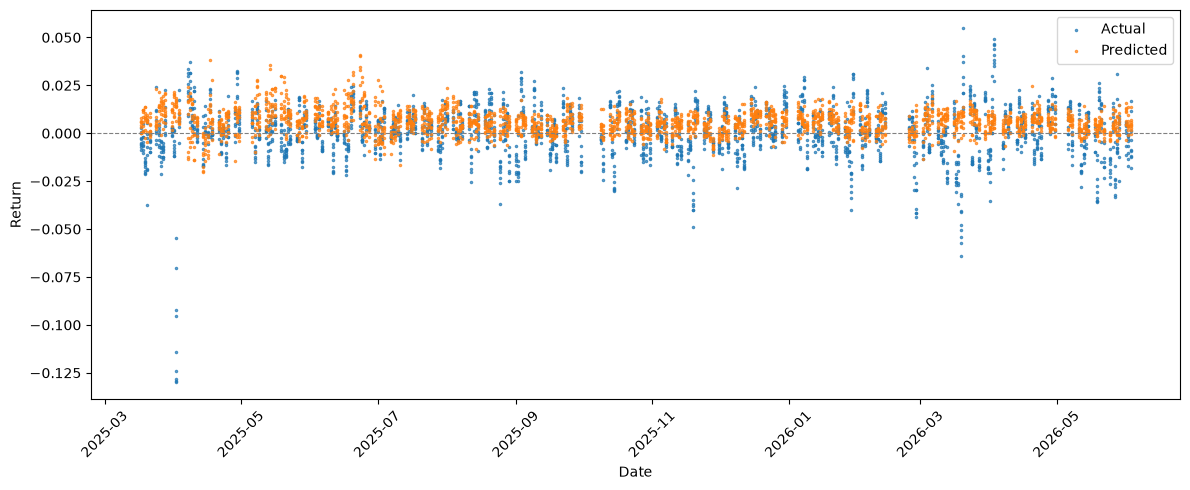

In [53]:
plt.figure(figsize=(12, 5))
plt.scatter(y_test.index.get_level_values('datetime'), y_test.values, s = 3, label="Actual", alpha=0.7, linewidth=0.8)
plt.scatter(y_test.index.get_level_values('datetime'), test_preds_mlp, s = 3, label="Predicted", alpha=0.7, linewidth=0.8)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

we can officially conclude that MLP is not suitable for this data set AT ALL
lets just try LSTM for project completeness

# LSTM

In [54]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [55]:
# build simple features
raw_df = df_clean.sort_index()
raw_df["log_ret"] = raw_df.groupby('code')['CLOSE'].transform(lambda x: np.log(x / x.shift(1)))
raw_df["vol_z"] = raw_df.groupby('code')["VOLUME"].transform(lambda x: (x-x.rolling(20).mean()) / x.rolling(20).std())
raw_df["hl_range"] = (raw_df["HIGH"] - raw_df["LOW"]) / raw_df["CLOSE"]
raw_df['STD20'] = raw_df.groupby('code')['CLOSE'].transform(lambda x: x.rolling(20).std() / x)

def resi30(close_series, window=30):
    resid = pd.Series(index=close_series.index, dtype=float)
    values = close_series.values
    for i in range(window - 1, len(values)):
        y = values[i - window + 1: i + 1]
        x = np.arange(window)
        # fit linear trend: y = a*x + b
        a, b = np.polyfit(x, y, 1)
        fitted_today = a * (window - 1) + b
        resid.iloc[i] = (values[i] - fitted_today) / values[i]
    return resid

raw_df['RESI30'] = raw_df.groupby('code')['CLOSE'].transform(lambda x: resi30(x))

def imin20(close_series, window=20):
    result = pd.Series(index=close_series.index, dtype=float)
    values = close_series.values
    for i in range(window - 1, len(values)):
        window_vals = values[i - window + 1: i + 1]
        min_pos_from_start = np.argmin(window_vals)          # 0 = start of window, window-1 = today
        days_ago = (window - 1) - min_pos_from_start          # 0 = today, window-1 = window start
        result.iloc[i] = days_ago / window
    return result

raw_df['IMIN20'] = raw_df.groupby('code')['CLOSE'].transform(lambda x: imin20(x))



# Label: next-day-after-next close-to-close return (realizable, per earlier discussion)
raw_df["label"] = raw_df.groupby('code')['CLOSE'].transform(lambda x: x.shift(-2) / x.shift(-1) - 1)

raw_df = raw_df.dropna()
raw_df = raw_df.drop(['PCT_CHG', 'AMT'], axis = 1)

feature_cols = ["log_ret", "vol_z", "hl_range", "STD20", "RESI30", "IMIN20"]

raw_df.head()

,date,OPEN,HIGH,LOW,CLOSE,VOLUME,code,log_ret,vol_z,hl_range,STD20,RESI30,IMIN20,label
29,2018-02-12,2803.8592,2823.8067,2776.9576,2805.2110,4.629000e+09,000016.SH,-0.001715,-1.865437,0.016701,0.039293,-0.099921,0.00,0.006685
30,2018-02-13,2834.3901,2887.8930,2834.3901,2852.7169,4.662221e+09,000016.SH,0.016793,-1.678676,0.018755,0.042681,-0.069913,0.05,0.020926
31,2018-02-14,2859.8663,2877.0369,2841.2391,2871.7873,2.534981e+09,000016.SH,0.006663,-2.286837,0.012465,0.045206,-0.052269,0.10,0.008626
32,2018-02-22,2915.9685,2936.8458,2900.8733,2931.8815,3.929775e+09,000016.SH,0.020710,-1.442048,0.012269,0.045225,-0.023210,0.15,0.005618
33,2018-02-23,2941.4214,2966.7522,2926.3629,2957.1710,3.820749e+09,000016.SH,0.008589,-1.336414,0.013658,0.045116,-0.008382,0.20,-0.015700


In [71]:
raw_df.describe()

,date,OPEN,HIGH,LOW,CLOSE,VOLUME,log_ret,vol_z,hl_range,STD20,RESI30,IMIN20,label
count,18099,18099.000000,18099.000000,18099.000000,18099.000000,1.809900e+04,18099.000000,18099.000000,18099.000000,18099.000000,18099.000000,18099.000000,18099.000000
mean,2022-04-07 13:21:59.343609856,27506.971755,27773.636379,27204.760914,27530.799878,2.320316e+10,0.000311,0.015546,0.016872,0.024185,0.000142,0.517407,0.000409
min,2018-02-12 00:00:00,1373.960900,1424.547200,1373.960900,1395.925700,5.207493e+08,-0.147350,-3.636784,0.000319,0.002914,-0.316430,0.000000,-0.137008
25%,2020-03-12 00:00:00,3016.241150,3040.468900,2996.621800,3017.883700,6.835005e+09,-0.006903,-0.846310,0.010117,0.014325,-0.014472,0.200000,-0.006901
50%,2022-04-08 00:00:00,4870.848200,4904.171600,4836.373900,4872.606100,1.579895e+10,0.000778,-0.128419,0.014240,0.020084,0.000450,0.550000,0.000762
75%,2024-05-08 00:00:00,6654.360250,6709.104700,6599.787100,6661.157500,3.001013e+10,0.008432,0.771988,0.020361,0.028485,0.014999,0.850000,0.008449
max,2026-06-03 00:00:00,644904.865100,646033.852600,638503.456700,645222.301600,2.790992e+11,0.229401,4.022877,0.154194,0.254373,0.218016,0.950000,0.257847
std,NaN,80706.001660,81481.330271,79794.707428,80752.549115,2.525761e+10,0.015219,1.141257,0.010632,0.015628,0.028935,0.337576,0.015192


In [83]:
print(raw_df["label"].describe()) 
####### this is the raw return, different from Alpha158

count    18099.000000
mean         0.000409
std          0.015192
min         -0.137008
25%         -0.006901
50%          0.000762
75%          0.008449
max          0.257847
Name: label, dtype: float64


In [56]:
# building sliding window
window = 20

X_seq, y_seq, dates_seq, codes_seq = [], [], [], []

for code, group in raw_df.groupby('code'):
    group = group.sort_values('date')
    values = group[feature_cols].values
    labels = group['label'].values
    dates = group['date'].values
    
    for i in range(window, len(group)):
        X_seq.append(values[i-window:i])
        y_seq.append(labels[i])
        dates_seq.append(dates[i])
        codes_seq.append(code)

X_seq = np.array(X_seq)   
y_seq = np.array(y_seq)
dates_seq = np.array(dates_seq)
codes_seq = np.array(codes_seq)

In [57]:
# test/valid/train split
dates_seq_pd = pd.to_datetime(dates_seq)   # ensure comparable datetime type

train_mask = (dates_seq_pd >= "2018-01-02") & (dates_seq_pd <= "2023-12-29")
valid_mask = (dates_seq_pd >= "2024-01-02") & (dates_seq_pd <= "2025-03-14")
test_mask  = (dates_seq_pd >= "2025-03-17") & (dates_seq_pd <= "2026-06-05")

X_train, y_train = X_seq[train_mask], y_seq[train_mask]
X_valid, y_valid = X_seq[valid_mask], y_seq[valid_mask]
X_test, y_test = X_seq[test_mask], y_seq[test_mask]
dates_test = dates_seq[test_mask]
codes_test = codes_seq[test_mask]

In [58]:
# 5. Simple LSTM model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]          # final layer's hidden state
        return self.fc(last_hidden).squeeze(-1)

model = LSTMRegressor(input_size=len(feature_cols))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # weight_decay = L2 reg
criterion = nn.MSELoss()

In [75]:
# 6. Training loop with manual early stopping on valid loss

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_valid_t = torch.tensor(X_valid, dtype=torch.float32)
y_valid_t = torch.tensor(y_valid, dtype=torch.float32)

best_valid_loss = float("inf")
patience, patience_counter = 20, 0
best_state = None

for epoch in range(500):
    model.train()
    optimizer.zero_grad()
    preds = model(X_train_t)
    loss = criterion(preds, y_train_t)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        valid_loss = criterion(model(X_valid_t), y_valid_t).item()

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)

Early stopping at epoch 313


<All keys matched successfully>

In [76]:
# 7. Evaluate on test set
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    test_preds = model(X_test_tensor).numpy()

test_index = pd.MultiIndex.from_arrays([dates_test, codes_test], names=["datetime", "instrument"])

eval_df = pd.DataFrame({"pred": test_preds, "actual": y_test}, index=test_index)

daily_ic = eval_df.groupby(level="datetime").apply(
    lambda g: g["pred"].corr(g["actual"], method="spearman")
)
rank_ic = daily_ic.mean()

mse = np.mean((y_test - test_preds) ** 2)
mae = np.mean(np.abs(y_test - test_preds))
corr = pd.Series(test_preds).corr(pd.Series(y_test))

print(f"Test MSE: {mse:.6f}")
print(f"Test MAE: {mae:.6f}")
print(f"Pearson corr: {corr:.4f}")
print(f"Rank IC: {rank_ic:.4f}")

Test MSE: 0.000238
Test MAE: 0.009832
Pearson corr: 0.0010
Rank IC: 0.0259


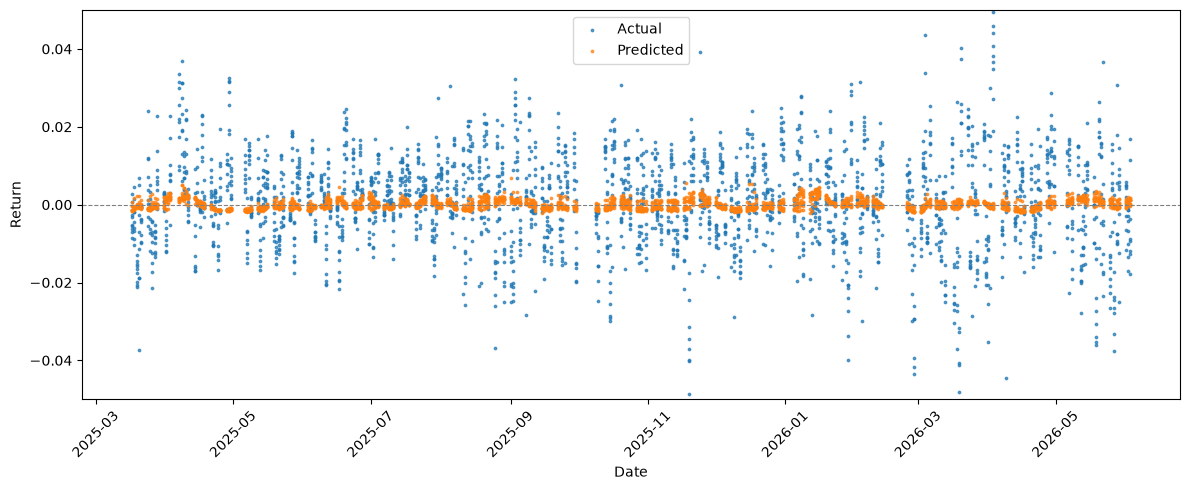

In [90]:
plt.figure(figsize=(12, 5))
plt.scatter(test_index.get_level_values('datetime'), y_test, s = 3, label="Actual", alpha=0.7)
plt.scatter(test_index.get_level_values('datetime'), test_preds, s = 3, label="Predicted", alpha=0.7)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Return")
plt.ylim(-0.05, 0.05)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [92]:
# lest check if the model recognizes a genral pattern
seeds = [0, 1, 42, 123, 7]
rank_ics = []

for seed in seeds:
    torch.manual_seed(seed)   # PyTorch's equivalent of sklearn's random_state
    
    model = LSTMRegressor(input_size=len(feature_cols))
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.MSELoss()
    
    best_valid_loss = float("inf")
    patience, patience_counter = 20, 0
    best_state = None

    for epoch in range(400):
        model.train()
        optimizer.zero_grad()
        preds = model(X_train_t)
        loss = criterion(preds, y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            valid_loss = criterion(model(X_valid_t), y_valid_t).item()

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        test_preds = model(X_test_tensor).numpy()

    test_index = pd.MultiIndex.from_arrays([dates_test, codes_test], names=["datetime", "instrument"])
    eval_df = pd.DataFrame({"pred": test_preds, "actual": y_test}, index=test_index)
    
    ic = eval_df.groupby(level="datetime").apply(lambda g: g["pred"].corr(g["actual"], method="spearman")).mean()

    rank_ics.append(ic)
    print(seed, ic)

print(f"\nMean: {np.mean(rank_ics):.4f}, Std: {np.std(rank_ics):.4f}")

0 0.016553672316384178
Early stopping at epoch 187
1 0.027376316209737264
42 -0.0035593220338983
Early stopping at epoch 235
123 -0.01553672316384181
Early stopping at epoch 84
7 0.039096045197740105

Mean: 0.0128, Std: 0.0199


- y = 0:
    - mse: 0.00018692912232227743 mae: 0.00962342807353104
- Ridge: 
    - MSE: 0.00018983546760864556 MAE: 0.009768844 corr: 0.06227176655449924 rank_ic: 0.016271186440677963
- LightGBM: 
    - MSE: 0.00018698142311200706 MAE: 0.0096016180204029 corr: 0.008931415230085752 rank_ic: 0.0003920664536337951
- MLP:
    - MSE: 0.00020431798 MAE: 0.01011178 corr: 0.027972189142707073 rank_ic: 0.0080225988700565
    - rank_ic stability: mean_ic: 0.011883239171374765 std_ic 0.019036297248195225
- LSTM: 
    - Test MSE: 0.000238, Test MAE: 0.009832, Pearson corr: 0.0010, Rank IC: 0.0259 (one round test)
    - rank_ic stability: Mean: 0.0128, Std: 0.0199

by comparison, Ridge is probably the best model
- next steps may include:
    - walk-through validation
    - protifolio construction then validate model usefullness